In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from scipy.stats import pearsonr
from scipy import stats
from scipy.spatial.distance import cdist
from statsmodels.stats.multitest import multipletests
from tqdm import tqdm
import re
import matplotlib.colors as mcolors
import networkx as nx
from itertools import combinations
import json
import random
from adjustText import adjust_text
import gget
from scipy.stats import spearmanr, kendalltau, wilcoxon
from networkx.algorithms.community import louvain_communities
from networkx.algorithms.community.quality import modularity
from matplotlib import colormaps
import matplotlib.patheffects as pe
import matplotlib.patches as patches

sc.settings.verbosity = 2

# A matrix

In [11]:
WORK_DIR = "/nfs/turbo/umms-indikar/Ram/development/projects/HardWiredGenome"

def generate_gene_id_name_map():
    # ENSEMBL_GENE_NAME_PATH = f"{WORK_DIR}/data/Gene Names.tsv"

    ENSEMBL_GENE_NAME_PATH = '/nfs/turbo/umms-indikar/shared/projects/HWG/data/ENSEMBL/Gene Names.tsv'
   
    usecols = ['Gene stable ID', 'Gene name']
    with open(ENSEMBL_GENE_NAME_PATH, 'r') as f:
        ensembl_gene_name_path = f.readlines()
    # ensembl_df = pd.read_csv(ENSEMBL_GENE_NAME_PATH, sep='\t', dtype=str, usecols=usecols, low_memory=False)

    ensmap = {}
    for row in ensembl_gene_name_path[1:]:
        splitrow = row.strip().split('\t')
        if len(splitrow) > 7:
            gene_id = splitrow[0]
            gene_name = splitrow[-1]
            ensmap[gene_id] = gene_name
                
    print(f'Extracted {len(ensmap)} mappings from {len(ensembl_gene_name_path)} ensembl lines')
        
    # gene_id_name_map = dict(zip(ensembl_df['Gene stable ID'], ensembl_df['Gene name']))
    
    NAME_MAP = '/nfs/turbo/umms-indikar/shared/projects/HWG/data/REFERENCE/gene_id_name_map_gtf.csv'
    
    # gene_id_name_map_gtf = pd.read_csv(f'{WORK_DIR}/data/gene_id_name_map_gtf.csv')
    gene_id_name_map_gtf = pd.read_csv(NAME_MAP)
    gene_id_name_map_dict = dict(zip(gene_id_name_map_gtf['gene_id'], gene_id_name_map_gtf['gene_name']))
    print(f'Extracted {len(gene_id_name_map_dict)} mappings from gene id gtf file')
    
    gene_id_name_map_dict.update(ensmap)
    
    name_id_map = {}
    for key, value in gene_id_name_map_dict.items():
        if value:
            name_id_map[value] = key

    print(f'Total Mappings Extracted {len(gene_id_name_map_dict)}')
    
    return gene_id_name_map_dict, name_id_map


DATA_DIRECTORY = '/nfs/turbo/umms-indikar/shared/projects/HWG/data/HWG/data'
# HUMAN_TF_IDLIST_PATH = f"{DATA_DIRECTORY}/HTF/TFs_Ensembl_v_1.01.txt"

HUMAN_TF_IDLIST_PATH = '/nfs/turbo/umms-indikar/shared/projects/HWG/data/HTF/TFs_Ensembl_v_1.01.txt'

def get_TF_set():
    # from constants import HUMAN_TF_IDLIST_PATH
    tflist = []
    with open(HUMAN_TF_IDLIST_PATH, 'r') as f:
        for line in f.readlines():
            tflist.append(line.strip())
    print(f'processed {len(tflist)} Transcription Factors')
    return tflist 

# Function to classify based on counts
def classify_effect(group):
    counts = group["Effect"].value_counts()
    activ = counts.get("Activation", 0)
    reprs = counts.get("Repression", 0)
    unkn  = counts.get("Unknown", 0)

    if activ > reprs:
        return "Activator"
    elif reprs > activ:
        return "Repressor"
    elif activ == reprs and (activ > 0 or reprs > 0):
        return "Conflicted"
    else:
        # Let's also make unknowns as conflicted.
        return "Conflicted"

    
    
# TRRUST_ACTIVITY_PATH = f"{DATA_DIRECTORY}/HTF/trrust_rawdata.human.tsv"
TRRUST_ACTIVITY_PATH = '/nfs/turbo/umms-indikar/shared/projects/HWG/data/HTF/trrust_rawdata.human.tsv'
    
def get_TF_activity_lists(log=True):

    tflist = get_TF_set()
    gene_id_name_map, gene_name_id_map = generate_gene_id_name_map() 

    TF_activity_TRRUST = pd.read_csv(TRRUST_ACTIVITY_PATH, sep='\t', header=None,  names=["TF","Target","Effect","PMID"])

    TF_activity_TRRUST["Effect"] = TF_activity_TRRUST["Effect"].astype(str).str.strip().str.capitalize()
    classification = TF_activity_TRRUST.groupby("TF").apply(classify_effect).reset_index(name="Class")


    activators = [str(gene_name_id_map.get(i)) for i in classification.loc[classification["Class"]=="Activator", "TF"].tolist()]
    repressors = [str(gene_name_id_map.get(i)) for i in classification.loc[classification["Class"]=="Repressor", "TF"].tolist()]
    conflicted = [str(gene_name_id_map.get(i)) for i in classification.loc[classification["Class"]=="Conflicted", "TF"].tolist()]
    unknowns   = [str(gene_name_id_map.get(i)) for i in classification.loc[classification["Class"]=="Unknown", "TF"].tolist()]
    
    if log:
        print(f' Total Activators : {len(activators)}')
        print(f'Total Reprossors : {len(repressors)}')
        print(f'Total Conflicted : {len(conflicted)}')
    
        print(f'Total Transcription Factors : {len(tflist)}')
    return repressors, activators, conflicted, tflist


def binarize(mat, thresh):
    if sp.issparse(mat):
        out = mat.copy()
        out.data = (out.data > thresh).astype(np.int8)
        return out
    else:
        return (mat > thresh).astype(np.int8)
    
def get_a_matrix_threshold(threshold):
    repressorlist, activatorlist, conflictedlist, tf_list = get_TF_activity_lists()
    
    A_PATH = '/nfs/turbo/umms-indikar/shared/projects/HWG/data/HWG/A_matrix.h5ad'
    
    # a_matrix_adata = an.read_h5ad('/nfs/turbo/umms-indikar/shared/projects/HWG/data/HWG/data/HWG/A_matrix.h5ad')
    a_matrix_adata = an.read_h5ad(A_PATH)
    a_matrix_adata.layers['HWG_0'] = a_matrix_adata.X
    a_bin = binarize(a_matrix_adata.layers['STRING'], threshold)
    b_bin = a_matrix_adata.layers['HURI']

    merged = a_bin + b_bin 

    if sp.issparse(merged):
        merged.data = np.ones_like(merged.data, dtype=np.int8)
    else:
        merged = (merged > 0).astype(np.int8)

    a_matrix_adata.layers[f'HWG_{threshold}'] = merged
    a_matrix_adata.X = merged

    b_matrix_true = a_matrix_adata[a_matrix_adata.obs_names.isin(tf_list)]

    c_matrix_true = a_matrix_adata[a_matrix_adata.obs_names.isin(tf_list), a_matrix_adata.var_names.isin(tf_list)]

    # c_matrix_true = a_matrix_adata[b_matrix_true.var_names.isin(tf_list)]
    
    return a_matrix_adata, b_matrix_true, c_matrix_true

In [12]:
# STRING score threshold 0-1000
thresh = 310

A, B, C = get_a_matrix_threshold(thresh)

print(A.shape)
print(B.shape)
print(C.shape)

processed 1639 Transcription Factors
Extracted 43945 mappings from 73467 ensembl lines
Extracted 38606 mappings from gene id gtf file
Total Mappings Extracted 59979


/tmp/ipykernel_1509238/46044993.py:88: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  classification = TF_activity_TRRUST.groupby("TF").apply(classify_effect).reset_index(name="Class")


 Total Activators : 329
Total Reprossors : 259
Total Conflicted : 207
Total Transcription Factors : 1639
(19678, 19678)
(1635, 19678)
(1635, 1635)


# Load gene info

In [13]:
%%time 
# === Load and filter GTF ===
gpath = "/scratch/indikar_root/indikar1/shared_data/HYB/resources/refdata-gex-GRCh38-2024-A_genes.csv.gz"

gtf = pd.read_csv(gpath)
print(gtf.shape)

print(gtf.columns.tolist())

gdf = gtf[['gene_id', 'gene_name', 'Feature', 'gene_type']].copy()
gdf = gdf[gdf['Feature'] == 'gene']
print(gdf.shape)

gdf = gdf.drop_duplicates('gene_id')

print(gdf.shape)
gdf.head()

(3293161, 27)
['Chromosome', 'Source', 'Feature', 'Start', 'End', 'Score', 'Strand', 'Frame', 'gene_id', 'gene_version', 'gene_type', 'gene_name', 'level', 'tag', 'transcript_id', 'transcript_version', 'transcript_type', 'transcript_name', 'transcript_support_level', 'havana_transcript', 'exon_number', 'exon_id', 'exon_version', 'hgnc_id', 'havana_gene', 'protein_id', 'ccdsid']
(38606, 4)
(38606, 4)
CPU times: user 12.8 s, sys: 1.88 s, total: 14.7 s
Wall time: 15 s


,gene_id,gene_name,Feature,gene_type
0,ENSG00000278704,ENSG00000278704,gene,protein_coding
8,ENSG00000277400,ENSG00000277400,gene,protein_coding
20,ENSG00000274847,MAFIP,gene,protein_coding
34,ENSG00000276256,ENSG00000276256,gene,protein_coding
44,ENSG00000277630,ENSG00000277630,gene,protein_coding


# Load cell cycle genes

In [14]:
### --------- load cell cycle genes ---------

# regev
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
print(f'Total regev genes: {len(regev_genes)}')


# GO
cdf = pd.read_csv("../../resources/human_cell_cycle_genes.csv")
cc_genes = cdf['gene_name'].unique()
print(f'\nTotal GO cell cycle genes: {len(cc_genes)}')


# KEGG (hsa04110) -- downloaded from GSEA website
kdf = pd.read_json("../../resources/KEGG_CELL_CYCLE.v2026.1.Hs.json")
kegg_genes = kdf.loc['geneSymbols', 'KEGG_CELL_CYCLE']
print(f'\nTotal KEGG cell cycle genes: {len(kegg_genes)}')


### combine into single list
all_cc_genes = list(set(regev_genes) | set(cc_genes) | set(kegg_genes))
print(f'\nGenes in combined list: {len(all_cc_genes)}')

Total regev genes: 97

Total GO cell cycle genes: 142

Total KEGG cell cycle genes: 125

Genes in combined list: 321


In [15]:
# get gene IDs from cc genes

print(all_cc_genes[:5])

cc_gdf = gdf[gdf['gene_name'].isin(all_cc_genes)].copy()
print(cc_gdf.shape)
print(cc_gdf['gene_id'].nunique())
print(cc_gdf['gene_name'].nunique())


cc_gene_ids = cc_gdf['gene_id'].unique()
print(len(cc_gene_ids))


cc_gdf.head()

['KIF2C', 'MYC', 'ECT2', 'NES', 'CDKN2B']
(300, 4)
300
300
300


,gene_id,gene_name,Feature,gene_type
28277,ENSG00000175793,SFN,gene,protein_coding
29779,ENSG00000180198,RCC1,gene,protein_coding
32686,ENSG00000121774,KHDRBS1,gene,protein_coding
34398,ENSG00000116478,HDAC1,gene,protein_coding
37420,ENSG00000134690,CDCA8,gene,protein_coding


# Make induced subgraph

In [16]:
# get A matrix with cc_genes
valid_genes = [g for g in cc_gene_ids if g in A.obs_names]
print(f"Found {len(valid_genes)} out of {len(cc_gene_ids)} genes.")


# get indices for these genes
indices = A.obs_names.get_indexer(valid_genes)

subX = A.X[indices, :][:, indices]


subA = pd.DataFrame(
    subX.toarray() if sp.issparse(subX) else subX, 
    index=valid_genes, 
    columns=valid_genes
)

print(f"Subnetwork shape: {subA.shape}")


# rename columns in subA to gene name
id_name_mapping = (cc_gdf.assign(gene_id=cc_gdf['gene_id'].astype(str), gene_name=cc_gdf['gene_name'].astype(str))
       .drop_duplicates('gene_id')
       .set_index('gene_id')['gene_name']
       .to_dict())

subA = subA.rename(index=lambda x: id_name_mapping.get(str(x), str(x)),
                   columns=lambda x: id_name_mapping.get(str(x), str(x)))

subA.head()

Found 300 out of 300 genes.
Subnetwork shape: (300, 300)


,SFN,RCC1,KHDRBS1,HDAC1,CDCA8,CDC20,KIF2C,PLK3,NASP,CDKN2C,...,SMC1B,POLA1,CCNB3,UBE2A,STAG2,PIM2,SMC1A,PHF8,CUL4B,USP26
SFN,1,0,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
RCC1,0,0,0,1,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
KHDRBS1,0,0,1,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
HDAC1,1,1,1,0,0,1,0,0,1,0,...,0,0,0,1,1,0,1,1,1,0
CDCA8,0,1,0,0,0,1,1,0,1,0,...,0,1,1,0,0,0,0,0,0,0


## Make graph

In [17]:
G = nx.from_pandas_adjacency(subA, create_using=nx.Graph) # keeps self-loops

# remove self-loops
G.remove_edges_from(nx.selfloop_edges(G))

print(f"N nodes: {G.number_of_nodes()}\nN edges: {G.number_of_edges()}")

degree_cent = nx.degree_centrality(G)
eigen_cent = nx.eigenvector_centrality(G, max_iter=1000)

deg = dict(G.degree()) # counts a self-loop as +2 in an undirected Graph  
# deg = {n: d - (1 if G.has_edge(n, n) else 0) for n, d in G.degree()} # counts self-loops as +1

avg_deg = sum(deg.values())/G.number_of_nodes()
print(f"Average degree: {avg_deg}")

print(f'Is connected? {nx.is_connected(G)}')
print(f'N connected components: {nx.number_connected_components(G)}')
print(f'Largest connected components has {len(max(nx.connected_components(G), key=len))} nodes')

# graph density 
n_edges = G.number_of_edges()
n_nodes = G.number_of_nodes()

density = (2 * n_edges) / (n_nodes * (n_nodes - 1))
print(f"Graph density: {density:.4f}")

df = pd.DataFrame({
    'degree': deg,
    'degree_cent': degree_cent,
    'eigenvector_cent': eigen_cent,
}).sort_values(by='eigenvector_cent', ascending=False)
print(df.shape)
df.head()

N nodes: 300
N edges: 11906
Average degree: 79.37333333333333
Is connected? False
N connected components: 2
Largest connected components has 299 nodes
Graph density: 0.2655
(300, 3)


,degree,degree_cent,eigenvector_cent
CDK1,227,0.759197,0.115083
CCNA2,206,0.688963,0.111735
CCNB1,211,0.705686,0.111343
CDC20,193,0.645485,0.108326
CDK2,210,0.702341,0.107534


# Load gene data

In [18]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups_v2.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 3.75 GB, difference +3.75 GB
CPU times: user 601 ms, sys: 1.76 s, total: 2.36 s
Wall time: 5.56 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [19]:
# save normalized counts
adata.X = adata.layers['raw_counts'].copy()

sc.pp.normalize_total(
    adata,
    target_sum=1e4,
)

adata.layers['CP10K'] = adata.X.copy()

adata

normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'mean', 'st

In [20]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
# regev_genes = [g for g in regev_genes if g in adata.var_names]

s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

adata.X = adata.layers['log_norm'].copy()

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs[['phase']].head()

calculating cell cycle phase
computing score 'S_score'
    finished (0:00:01)
computing score 'G2M_score'
    finished (0:00:00)
CPU times: user 1.63 s, sys: 718 ms, total: 2.35 s
Wall time: 2.4 s


,phase
AAACCAAAGCAACTGC_hybrid,G2M
AAACCAAAGTAGGGCA_hybrid,S
AAACCAAAGTCTAGGC_hybrid,G1
AAACCATTCACGTAAT_hybrid,G2M
AAACCATTCAGGCAGA_hybrid,G2M


In [21]:
# Create a collapsed phase column
adata.obs['phase_grouped'] = adata.obs['phase'].replace({
    'G1': 'G1S',
    'S': 'G1S',
    'G2M': 'G2M'
})

# Create the combined grouping column
adata.obs['cond_phase_group'] = (
    adata.obs['pooled_condition'].astype(str) + '_' +
    adata.obs['phase_grouped'].astype(str)
)

adata.obs["cond_phase_group"].value_counts(sort=False)

cond_phase_group
siPRRX1/mmMYOD1_G2M     571
mmMYOD1_G1S            2022
siPRRX1/mmMYOD1_G1S    2885
siPRRX1_G2M            1281
mmMYOD1_G2M             233
siPRRX1_G1S            2402
Control_G2M            1958
Control_G1S            4944
Name: count, dtype: int64

## Make base subgraph

In [22]:
#### Make base subgraph over all cells

conds = ['Control', 'mmMYOD1', 'siPRRX1/mmMYOD1']

fdata = adata[adata.obs['pooled_condition'].isin(conds), :].copy()

### Which genes are present in adata?
gene_names = set(fdata.var_names)
gene_ids = set(fdata.var['gene_id'])
cc_nodes = list(G.nodes())
print(len(cc_nodes))
cc_genes = [g for g in cc_nodes if g in fdata.var_names]
missing_cc_genes = list(set(cc_nodes) - set(cc_genes))
print(f"N cc nodes in adata: {len(cc_genes)}")
print(f"{len(missing_cc_genes)} genes not detected.\n")
print("Missing genes:", ", ".join(missing_cc_genes))


### pseudobulk
func = 'mean'

aggdata = sc.get.aggregate(
    fdata,
    by='pooled_condition',
    func=func,
    layer='CP10K',
)

aggdata.X = aggdata.layers[f'{func}'].copy()
X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()
df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T
df = df.reset_index()
print(df.shape)
df.head()


cdf = df[df['gene_name'].isin(cc_nodes)].copy()
print(cdf.shape)


# ---------- Add % expressing per condition columns ----------
def pct_expressing_by_group(adata, group_key, genes, layer="raw_counts", threshold=0):
    # subset to genes of interest
    genes = [g for g in genes if g in adata.var_names]
    A = adata[:, genes].layers[layer]
    if not sp.issparse(A):
        A = sp.csr_matrix(A)

    groups = adata.obs[group_key].astype(str).values
    out = pd.DataFrame(index=genes)

    for g in np.unique(groups):
        idx = np.where(groups == g)[0]
        sub = A[idx, :]
        pct = (sub > threshold).mean(axis=0)  # fraction expressing
        pct = np.asarray(pct).ravel()
        out[f"pct_expr_{g}"] = pct

    out.index.name = "gene_name"
    return out.reset_index()

# % expressing
pct_df = pct_expressing_by_group(fdata, group_key="pooled_condition", genes=list(G.nodes()), layer="raw_counts", threshold=0)

cdf = cdf.merge(pct_df, on='gene_name', how='left')
print(cdf.shape)
cdf.head()

# set to 0 for low genes
pct_prefix = 'pct_expr_'
min_pct = 0.10 # 10%

for cond in conds:
    pct_col = f"{pct_prefix}{cond}"
    expr_col = cond
    cdf.loc[cdf[pct_col] < min_pct, expr_col] = 0
    
display(cdf.head())

# get UNION node set
node_list = cdf[~((cdf[f'Control'] == 0) & (cdf[f'mmMYOD1'] == 0) & (cdf[f'siPRRX1/mmMYOD1'] == 0))]['gene_name'].unique()
print(f'N genes expressed in at least one group: {len(node_list)}')

300
N cc nodes in adata: 293
7 genes not detected.

Missing genes: PTTG2, DRD2, DRD3, WEE2, USP29, TRIM71, USH1C
(25126, 4)
(293, 4)
(293, 7)


,gene_name,Control,mmMYOD1,siPRRX1/mmMYOD1,pct_expr_Control,pct_expr_mmMYOD1,pct_expr_siPRRX1/mmMYOD1
0,ABCB1,0.000000,0.000000,0.000000,0.001449,0.023060,0.022280
1,ABL1,0.189989,0.546279,0.405190,0.234280,0.384479,0.358218
2,ACVR1B,0.000000,0.000000,0.000000,0.051579,0.086475,0.077546
3,AMBRA1,0.454003,0.604057,0.584996,0.474500,0.461197,0.501157
4,ANAPC1,0.084858,0.308042,0.254943,0.113590,0.261197,0.258391


N genes expressed in at least one group: 256


In [23]:
## base subgraph
subG = G.subgraph(node_list).copy()
n_edges = subG.number_of_edges()
n_nodes = subG.number_of_nodes()
print(f"Control - N nodes: {n_nodes}, N edges: {n_edges}")
print(f"Density = {(2 * n_edges) / (n_nodes * (n_nodes - 1)):.4f}")

Control - N nodes: 256, N edges: 10036
Density = 0.3075


In [24]:
subG_nodes = subG.nodes()
G_nodes = G.nodes()

missing_nodes = list(set(G_nodes) - set(subG_nodes))
print(len(missing_nodes))
print(", ".join(sorted(missing_nodes)))

44
ABCB1, ACVR1B, ANAPC2, BCL2, BRSK1, BRSK2, CAMK2A, CCNA1, CCNB3, CCND2, CCNE1, CDC25A, CDC45, CDK3, CDKN1C, CDKN2B, DRD2, DRD3, DRD4, E2F1, E2F2, E2F5, GADD45G, GPR132, HINFP, ID4, KDM8, PIM2, PTTG2, RGCC, RHOU, SFN, SMC1B, SYCP2, SYCP2L, TGFB3, TPD52L1, TRIM71, USH1C, USP26, USP29, WEE2, WNT10B, ZNF324


# Pseudobulk

Pseudobulk --> weights = product of normalized expression --> absolute magnitude 
* sensitive to technical bias...
* bootstrapping could help give CI

In [25]:
# subset for conditions of interest
phase = 'G1S'

conds = [f'Control_{phase}', f'mmMYOD1_{phase}', f'siPRRX1/mmMYOD1_{phase}']

fdata = adata[adata.obs['cond_phase_group'].isin(conds), :].copy()


### Which genes are present in adata?
gene_names = set(fdata.var_names)
gene_ids = set(fdata.var['gene_id'])


cc_nodes = list(G.nodes())
print(len(cc_nodes))

cc_genes = [g for g in cc_nodes if g in fdata.var_names]

missing_cc_genes = list(set(cc_nodes) - set(cc_genes))


print(f"N cc nodes in adata: {len(cc_genes)}")
print(f"{len(missing_cc_genes)} genes not detected.\n")
print("Missing genes:", ", ".join(missing_cc_genes))


fdata

300
N cc nodes in adata: 293
7 genes not detected.

Missing genes: PTTG2, DRD2, DRD3, WEE2, USP29, TRIM71, USH1C


AnnData object with n_obs × n_vars = 9851 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'phase_grouped', 'cond_phase_group'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_to

In [26]:
### mean of normalized counts
func = 'mean'

aggdata = sc.get.aggregate(
    fdata,
    by='cond_phase_group',
    func=func,
    layer='CP10K',
)

aggdata.X = aggdata.layers[f'{func}'].copy()

X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()

df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T

df = df.reset_index()

print(df.shape)
df.head()

(25126, 4)


,gene_name,Control_G1S,mmMYOD1_G1S,siPRRX1/mmMYOD1_G1S
0,A1BG,0.879720,0.509188,0.473986
1,A1BG-AS1,0.049147,0.102617,0.085654
2,A1CF,0.000259,0.010147,0.008091
3,A2M,0.153082,0.011135,0.015467
4,A2M-AS1,0.003037,0.003964,0.002996


In [27]:
print(df[conds].sum())
df[conds].describe()

Control_G1S            10000.000007
mmMYOD1_G1S             9999.999995
siPRRX1/mmMYOD1_G1S     9999.999988
dtype: float64


,Control_G1S,mmMYOD1_G1S,siPRRX1/mmMYOD1_G1S
count,25126.000000,25126.000000,25126.000000
mean,0.397994,0.397994,0.397994
std,3.340188,2.493465,2.779530
min,0.000000,0.000000,0.000000
25%,0.001570,0.008924,0.006760
50%,0.019836,0.056332,0.044595
75%,0.147845,0.253903,0.220506
max,285.321724,197.015264,205.916428


In [28]:
cdf = df[df['gene_name'].isin(cc_nodes)].copy()
print(cdf.shape)


# ---------- Add % expressing per condition columns ----------
def pct_expressing_by_group(adata, group_key, genes, layer="raw_counts", threshold=0):
    # subset to genes of interest
    genes = [g for g in genes if g in adata.var_names]
    A = adata[:, genes].layers[layer]
    if not sp.issparse(A):
        A = sp.csr_matrix(A)

    groups = adata.obs[group_key].astype(str).values
    out = pd.DataFrame(index=genes)

    for g in np.unique(groups):
        idx = np.where(groups == g)[0]
        sub = A[idx, :]
        pct = (sub > threshold).mean(axis=0)  # fraction expressing
        pct = np.asarray(pct).ravel()
        out[f"pct_expr_{g}"] = pct

    out.index.name = "gene_name"
    return out.reset_index()

# compute for MYOD network genes
pct_df = pct_expressing_by_group(
    fdata, group_key="cond_phase_group", genes=list(G.nodes()), layer="raw_counts", threshold=0
)

cdf = cdf.merge(pct_df, on='gene_name', how='left')
print(cdf.shape)
cdf.head()

(293, 4)
(293, 7)


,gene_name,Control_G1S,mmMYOD1_G1S,siPRRX1/mmMYOD1_G1S,pct_expr_Control_G1S,pct_expr_mmMYOD1_G1S,pct_expr_siPRRX1/mmMYOD1_G1S
0,ABCB1,0.001574,0.038488,0.027230,0.001820,0.025717,0.023570
1,ABL1,0.182548,0.556020,0.407720,0.210761,0.382789,0.355633
2,ACVR1B,0.037344,0.101618,0.064911,0.047735,0.086053,0.076256
3,AMBRA1,0.443871,0.600345,0.592093,0.443972,0.454500,0.498094
4,ANAPC1,0.079091,0.302619,0.248812,0.100121,0.253709,0.245407


In [29]:
print(cdf[conds].sum())
cdf[conds].describe()

Control_G1S            218.810591
mmMYOD1_G1S            222.895029
siPRRX1/mmMYOD1_G1S    233.623675
dtype: float64


,Control_G1S,mmMYOD1_G1S,siPRRX1/mmMYOD1_G1S
count,293.000000,293.000000,293.000000
mean,0.746794,0.760734,0.797350
std,2.296553,1.797275,1.875209
min,0.000000,0.000170,0.000926
25%,0.098954,0.169929,0.154109
50%,0.243614,0.331483,0.335679
75%,0.539279,0.690748,0.696098
max,29.699269,22.164392,23.680358


In [30]:
# ---------- Set expr to 0 for genes expressed in less than 10% of cells per group ----------
# conditions = ['Control_G1S', f'{cond}']#, 'siPRRX1', 'siPRRX1/mmMYOD1']
pct_prefix = 'pct_expr_'
min_pct = 0.10 # 10%

for cond in conds:
    pct_col = f"{pct_prefix}{cond}"
    expr_col = cond
    cdf.loc[cdf[pct_col] < min_pct, expr_col] = 0
    
display(cdf.head())

# pct_cols = [pct_prefix + cond for cond in conditions]

print(f"\nN genes expressed in >= 10% of cells for...\n")

total_genes = cdf.shape[0]

for col in conds:
    nonzero_genes = (cdf[col] != 0).sum()
    print(f"{col}: {nonzero_genes} genes\n% of total nodes = {nonzero_genes/total_genes*100:.2f}%\n")

,gene_name,Control_G1S,mmMYOD1_G1S,siPRRX1/mmMYOD1_G1S,pct_expr_Control_G1S,pct_expr_mmMYOD1_G1S,pct_expr_siPRRX1/mmMYOD1_G1S
0,ABCB1,0.000000,0.000000,0.000000,0.001820,0.025717,0.023570
1,ABL1,0.182548,0.556020,0.407720,0.210761,0.382789,0.355633
2,ACVR1B,0.000000,0.000000,0.000000,0.047735,0.086053,0.076256
3,AMBRA1,0.443871,0.600345,0.592093,0.443972,0.454500,0.498094
4,ANAPC1,0.079091,0.302619,0.248812,0.100121,0.253709,0.245407



N genes expressed in >= 10% of cells for...

Control_G1S: 232 genes
% of total nodes = 79.18%

mmMYOD1_G1S: 240 genes
% of total nodes = 81.91%

siPRRX1/mmMYOD1_G1S: 246 genes
% of total nodes = 83.96%



In [31]:
# create subgraph with only expressed nodes per condition, then assign weights
def add_edge_weights_from_node_activity(G, a, weight_attr="weight", combine="product"):
    Gw = G.copy()
    for u, v in Gw.edges():
        au = a.get(u, 0.0)
        av = a.get(v, 0.0)
        if combine == "product":
            w = au * av
        elif combine == "min":
            w = min(au, av)
        elif combine == "mean":
            w = 0.5 * (au + av)
        else:
            raise ValueError("combine must be 'product', 'min', or 'mean'")
        Gw[u][v][weight_attr] = float(w)
        # Create a distance attribute: small value for high activity
        # We add a tiny epsilon (1e-9) to avoid division by zero
        Gw[u][v]["distance"] = 1.0 / (float(w) + 1e-9)
    return Gw

def edge_weight_series(G):
    return [d.get("weight", 0.0) for _, _, d in G.edges(data=True)]


# ---------- Create weighted subgraphs from subG ----------

print("Base subgraph:", f"\n\tN nodes - {subG.number_of_nodes()} \n\tN edges - {subG.number_of_edges()}")

## Control
a_ctrl = dict(zip(cdf["gene_name"], cdf[f"Control_{phase}"]))
wCGM = add_edge_weights_from_node_activity(subG, a_ctrl, weight_attr="weight", combine="product")


## mmMYOD1
a_mmy = dict(zip(cdf["gene_name"], cdf[f'mmMYOD1_{phase}']))
wMGM = add_edge_weights_from_node_activity(subG, a_mmy, weight_attr="weight", combine="product")


## HYB
a_hyb = dict(zip(cdf["gene_name"], cdf[f'siPRRX1/mmMYOD1_{phase}']))
wHGM = add_edge_weights_from_node_activity(subG, a_hyb, weight_attr="weight", combine="product")


if ((wCGM.number_of_nodes() != wMGM.number_of_nodes()) | (wCGM.number_of_nodes() != wHGM.number_of_nodes())):
    print("!!! Not the same node set !!!")


    
ctrl_sum = sum(edge_weight_series(wCGM))
print(f"\nSum edge weight (Control): {ctrl_sum:.3f}")
m_sum = sum(edge_weight_series(wMGM))
print(f"Sum edge weight (mmMYOD1): {m_sum:.3f}")
h_sum = sum(edge_weight_series(wHGM))
print(f"Sum edge weight (HYB): {h_sum:.3f}")

Base subgraph: 
	N nodes - 256 
	N edges - 10036

Sum edge weight (Control): 5642.850
Sum edge weight (mmMYOD1): 5734.961
Sum edge weight (HYB): 6894.949


In [32]:
### Fold-change in total edge weights
def total_w(G, weight="weight"):
    return sum(d.get(weight, 0.0) for _,_,d in G.edges(data=True))

Wc = total_w(wCGM)
Wm = total_w(wMGM)
Wh = total_w(wHGM)

print("Edges:", subG.number_of_edges(), " Nodes:", subG.number_of_nodes())

print("\nTotal weight control:", f"{Wc:.4f}")
print(f"Total weight mmMYOD1: {Wm:.4f}")
print(f"Total weight HYB: {Wh:.4f}")

print("\nFold-change (mmMYOD1/ctrl):", f"{(Wm / Wc if Wc else np.nan):.4f}")
print("log2FC:", f"{np.log2((Wm + 1e-12)/(Wc + 1e-12)):.4f}")

print("\nFold-change (HYB/ctrl):", f"{(Wh / Wc if Wc else np.nan):.4f}")
print("log2FC:", f"{np.log2((Wh + 1e-12)/(Wc + 1e-12)):.4f}")

print("\nFold-change (HYB/mmMYOD1):", f"{(Wh / Wm if Wm else np.nan):.4f}")
print("log2FC:", f"{np.log2((Wh + 1e-12)/(Wm + 1e-12)):.4f}")

Edges: 10036  Nodes: 256

Total weight control: 5642.8501
Total weight mmMYOD1: 5734.9606
Total weight HYB: 6894.9486

Fold-change (mmMYOD1/ctrl): 1.0163
log2FC: 0.0234

Fold-change (HYB/ctrl): 1.2219
log2FC: 0.2891

Fold-change (HYB/mmMYOD1): 1.2023
log2FC: 0.2658


In [33]:
### Per-edge log2FC
eps = 1e-12
edges = list(subG.edges())

# vectors of edge weights (aligned across the same edges)
wc = np.array([wCGM[u][v]["weight"] for u,v in edges], float)
wm = np.array([wMGM[u][v]["weight"]  for u,v in edges], float)
wh = np.array([wHGM[u][v]["weight"]  for u,v in edges], float)

# optional: drop edges that are zero in all (uninformative)
mask = ~((wc == 0) & (wm == 0) & (wh == 0))
wc1, wm1, wh1 = wc[mask], wm[mask], wh[mask]
print(f'Retained edges: {mask.sum()} ({len(edges) - mask.sum()} dropped)')

# per-edge log2FC
log2_ratio = np.log2((wm1 + eps) / (wc1 + eps))
log2_ratio_hc = np.log2((wh1 + eps) / (wc1 + eps))
log2_ratio_hm = np.log2((wh1 + eps) / (wm1 + eps))

print(f"\nMedian log2 ratio (M / C): {np.median(log2_ratio):.4f}")
print(f"Mean log2 ratio (M / C): {np.mean(log2_ratio):.4f}")
print(f"\tFraction edges increased: {np.mean(wm1 > wc1):.4f}")
print(f"\tFraction edges decreased: {np.mean(wm1 < wc1):.4f}")

print(f"\nMedian log2 ratio (H / C): {np.median(log2_ratio_hc):.4f}")
print(f"Mean log2 ratio (H / C): {np.mean(log2_ratio_hc):.4f}")
print(f"\tFraction edges increased: {np.mean(wh1 > wc1):.4f}")
print(f"\tFraction edges decreased: {np.mean(wh1 < wc1):.4f}")

print(f"\nMedian log2 ratio (H / M): {np.median(log2_ratio_hm):.4f}")
print(f"Mean log2 ratio (H / M): {np.mean(log2_ratio_hm):.4f}")
print(f"\tFraction edges increased: {np.mean(wh1 > wm1):.4f}")
print(f"\tFraction edges decreased: {np.mean(wh1 < wm1):.4f}")

Retained edges: 9484 (552 dropped)

Median log2 ratio (M / C): 0.2990
Mean log2 ratio (M / C): 0.5812
	Fraction edges increased: 0.5956
	Fraction edges decreased: 0.3675

Median log2 ratio (H / C): 0.7264
Mean log2 ratio (H / C): 3.9265
	Fraction edges increased: 0.8042
	Fraction edges decreased: 0.1904

Median log2 ratio (H / M): 0.3306
Mean log2 ratio (H / M): 3.3453
	Fraction edges increased: 0.6962
	Fraction edges decreased: 0.2760


Retained edges: 9484 (552 dropped)
7880


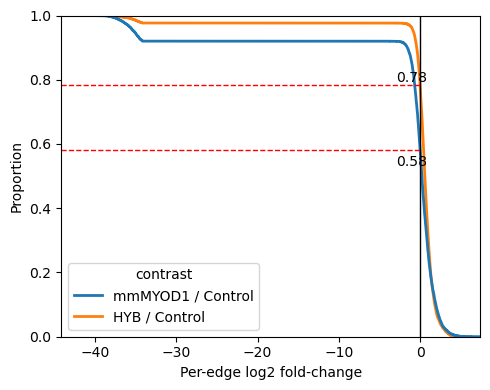

,contrast,log2FC
0,mmMYOD1 / Control,0.452739
1,mmMYOD1 / Control,0.989389
2,mmMYOD1 / Control,1.678831
3,mmMYOD1 / Control,0.806930
4,mmMYOD1 / Control,1.832269


In [34]:
### Per-edge log2FC
eps = 1e-12
edges = list(subG.edges())

# vectors of edge weights (aligned across the same edges)
wc = np.array([wCGM[u][v]["weight"] for u,v in edges], float)
wm = np.array([wMGM[u][v]["weight"]  for u,v in edges], float)
wh = np.array([wHGM[u][v]["weight"]  for u,v in edges], float)

# drop edges that are zero in all (uninformative)
mask = ~((wc == 0) & (wm == 0) & (wh == 0))
wc1, wm1, wh1 = wc[mask], wm[mask], wh[mask]
print(f'Retained edges: {mask.sum()} ({len(edges) - mask.sum()} dropped)')


min_den = np.quantile(wc1[wc1 > 0], 0.05)  # e.g., keep top 95% of nonzero denominators
keep = wc1 >= min_den
print(keep.sum())

log2_mc = np.log2((wm1[keep] + eps) / (wc1[keep] + eps))
log2_hc = np.log2((wh1[keep] + eps) / (wc1[keep] + eps))


# min_den_mmy = np.quantile(wm1[wm1 > 0], 0.05)
# keep_mmy = wm1 >= min_den_mmy
# print(keep_mmy.sum())

# log2_hm = np.log2((wh1[keep_mmy] + eps) / (wm1[keep_mmy] + eps))



plot_df = pd.DataFrame({
    "mmMYOD1 / Control": log2_mc,
    "HYB / Control":     log2_hc,
    # "HYB / mmMYOD1":     log2_hm,
}).melt(var_name="contrast", value_name="log2FC")

# ---- ECDF plot ----
plt.figure(figsize=(5, 4))

sns.ecdfplot(
    data=plot_df,
    x="log2FC", 
    hue="contrast", 
    linewidth=2, 
    complementary=True,
)

plt.axvline(0, color="black", lw=1)
plt.xlabel("Per-edge log2 fold-change")
# plt.xscale('log')

ax = plt.gca()
xmin, xmax = ax.get_xlim()
for contrast, group in plot_df.groupby('contrast'):
    vals = group['log2FC'].values
    
    # ECDF value at x = 0
    y = np.mean(vals >= 0) # because complementary = True
    ax.hlines(y, xmin=xmin, xmax=0, ls='--', lw=1, color='red')
    
    if contrast == 'HYB / Control':
        ax.text(-3, y+0.01, s=f'{y:.2f}')
    else:
        ax.text(-3, y-0.05, s=f'{y:.2f}')


ax.margins(x=0)
plt.tight_layout()
plt.show()

plot_df.head()

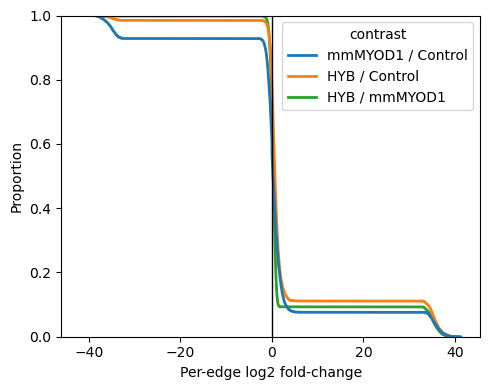

In [81]:
plot_df = pd.DataFrame({
    "mmMYOD1 / Control": log2_ratio,
    "HYB / Control":     log2_ratio_hc,
    "HYB / mmMYOD1":     log2_ratio_hm,
}).melt(var_name="contrast", value_name="log2FC")

# ---- ECDF plot ----
plt.figure(figsize=(5, 4))
sns.ecdfplot(
    data=plot_df,
    x="log2FC", 
    hue="contrast", 
    linewidth=2, 
    complementary=True,
)

plt.axvline(0, color="black", lw=1)
plt.xlabel("Per-edge log2 fold-change")
# plt.xscale('log')


plt.tight_layout()
plt.show()

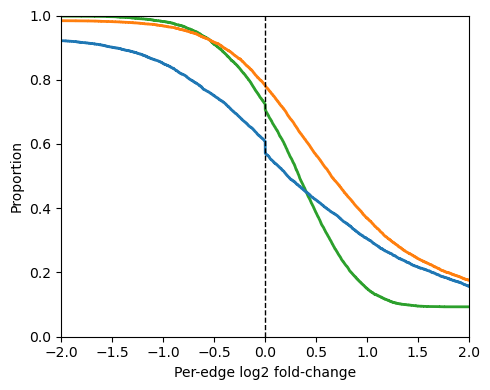

In [82]:
# ---- ECDF plot ----
plt.figure(figsize=(5, 4))
sns.ecdfplot(
    data=plot_df,
    x="log2FC", 
    hue="contrast", 
    linewidth=2, 
    complementary=True,
    legend=False,
)

plt.axvline(0, color="black", lw=1, ls='--')
plt.xlabel("Per-edge log2 fold-change")
plt.xlim(-2, 2)


plt.tight_layout()
plt.show()

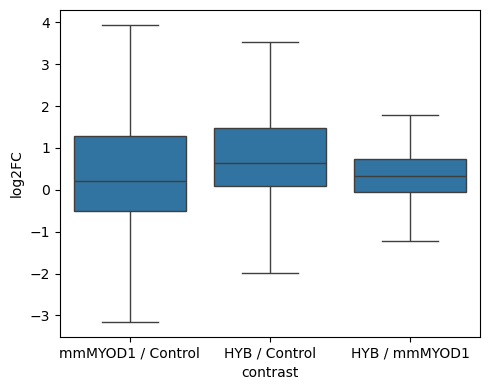

In [83]:
plt.figure(figsize=(5, 4))

sns.boxplot(
    data=plot_df,
    x='contrast',
    y='log2FC',
    showfliers=False,
)

plt.tight_layout()
plt.show()

# Bootstrapping

In [35]:
subsample_frac = 0.8

phase = 'G1S'
condition_order = [f'Control_{phase}', f'mmMYOD1_{phase}', f'siPRRX1/mmMYOD1_{phase}']


# Get cell indices per condition
condition_indices = {
    cond: np.where(adata.obs['cond_phase_group'] == cond)[0]
    for cond in condition_order
}
# Use smallest condition size to determine subsample size
min_cells = min(len(idx) for idx in condition_indices.values())
n_subsample = int(min_cells * subsample_frac)
print(f"Cells per condition: { {c: len(v) for c, v in condition_indices.items()} }")
print(f"Subsampling {n_subsample} cells per condition per iteration")

Cells per condition: {'Control_G1S': 4944, 'mmMYOD1_G1S': 2022, 'siPRRX1/mmMYOD1_G1S': 2885}
Subsampling 1617 cells per condition per iteration


In [52]:
def _dense_float32(A):
    if sp.issparse(A):
        A = A.toarray()
    return np.asarray(A, dtype=np.float32)

def bootstrap_edge_weight_sums_fast_from_subG(
    adata,
    subG,                       # your pre-filtered fixed graph topology
    conds,
    group_key="cond_phase_group",
    layer_expr="CP10K",
    layer_raw="raw_counts",
    min_pct=0.10,
    raw_threshold=0,
    combine="product",          # "product", "min", "mean"
    n_boot=1000,
    frac=0.8,
    sample_mode="fixed_n_by_min",  # "fixed_n_by_min" or "frac_each"
    seed=0,
):
    rng = np.random.default_rng(seed)

    # subset once
    fdata = adata[adata.obs[group_key].isin(conds), :]

    # fixed node order from subG
    node_list = list(subG.nodes())
    # keep only nodes present in adata
    # node_list = [g for g in node_list if g in fdata.var_names]
    if len(node_list) == 0:
        raise ValueError("No subG nodes are present in adata.var_names after subsetting.")

    # edge endpoint indices (relative to node_list)
    gene_to_pos = {g: i for i, g in enumerate(node_list)}
    edges = [(u, v) for u, v in subG.edges() if (u in gene_to_pos and v in gene_to_pos)]
    if len(edges) == 0:
        raise ValueError("No edges remain after intersecting subG nodes with adata.var_names.")

    u_idx = np.fromiter((gene_to_pos[u] for u, v in edges), count=len(edges), dtype=np.int32)
    v_idx = np.fromiter((gene_to_pos[v] for u, v in edges), count=len(edges), dtype=np.int32)

    # per-condition cell indices
    groups = fdata.obs[group_key].astype(str).to_numpy()
    cond_to_rows = {c: np.where(groups == c)[0] for c in conds}
    group_sizes = {c: len(cond_to_rows[c]) for c in conds}
    min_group_size = min(group_sizes.values())

    # choose bootstrap n per group
    if sample_mode == "fixed_n_by_min":
        n_fixed = max(1, int(np.floor(frac * min_group_size)))
        n_per = {c: n_fixed for c in conds}
    elif sample_mode == "frac_each":
        n_per = {c: max(1, int(np.floor(frac * group_sizes[c]))) for c in conds}
    else:
        raise ValueError("sample_mode must be 'fixed_n_by_min' or 'frac_each'.")

    # extract matrices once (cells x genes)
    X_expr = _dense_float32(fdata[:, node_list].layers[layer_expr])

    X_raw = fdata[:, node_list].layers[layer_raw]
    if sp.issparse(X_raw):
        X_bin = (X_raw.tocsr() > raw_threshold).toarray().astype(np.float32)
    else:
        X_bin = (np.asarray(X_raw) > raw_threshold).astype(np.float32)

    # bootstrap
    out = np.empty((n_boot, len(conds)), dtype=np.float64)

    for b in range(n_boot):
        for j, c in enumerate(conds):
            rows = cond_to_rows[c]
            n_samp = n_per[c]
            samp = rng.choice(rows, size=n_samp, replace=True)

            mu = X_expr[samp, :].mean(axis=0)     # mean CP10K
            pct = X_bin[samp, :].mean(axis=0)     # fraction expressing

            mu = mu.copy()
            mu[pct < min_pct] = 0.0

            if combine == "product":
                out[b, j] = np.sum(mu[u_idx] * mu[v_idx])
            elif combine == "min":
                out[b, j] = np.sum(np.minimum(mu[u_idx], mu[v_idx]))
            elif combine == "mean":
                out[b, j] = 0.5 * np.sum(mu[u_idx] + mu[v_idx])
            else:
                raise ValueError("combine must be 'product', 'min', or 'mean'.")

    boot_df = pd.DataFrame(out, columns=conds)

    info = {
        "n_nodes_used": len(node_list),
        "n_edges_used": len(edges),
        "group_sizes": group_sizes,
        "n_per_group": n_per,
        "sample_mode": sample_mode,
        "frac": frac,
        "min_pct": min_pct,
        "combine": combine,
        "layers": (layer_expr, layer_raw),
    }
    return boot_df, info, node_list, edges

In [53]:
%%time
phase = "G2M"
# phase = "G1S"
conds = [f"Control_{phase}", f"mmMYOD1_{phase}", f"siPRRX1/mmMYOD1_{phase}"]

boot_df, info, node_list, edges = bootstrap_edge_weight_sums_fast_from_subG(
    adata=adata,
    subG=subG,     # <-- your precomputed union-filtered graph
    conds=conds,
    group_key="cond_phase_group",
    # layer_expr="CP10K",
    layer_expr='log_norm',
    layer_raw="raw_counts",
    min_pct=0.10,
    combine="product",
    n_boot=1000,
    frac=0.8,
    sample_mode="fixed_n_by_min",
    seed=1,
)

print(info)
boot_df.quantile([0.025, 0.5, 0.975])

{'n_nodes_used': 256, 'n_edges_used': 10036, 'group_sizes': {'Control_G2M': 1958, 'mmMYOD1_G2M': 233, 'siPRRX1/mmMYOD1_G2M': 571}, 'n_per_group': {'Control_G2M': 186, 'mmMYOD1_G2M': 186, 'siPRRX1/mmMYOD1_G2M': 186}, 'sample_mode': 'fixed_n_by_min', 'frac': 0.8, 'min_pct': 0.1, 'combine': 'product', 'layers': ('log_norm', 'raw_counts')}
CPU times: user 719 ms, sys: 92.2 ms, total: 811 ms
Wall time: 830 ms


,Control_G2M,mmMYOD1_G2M,siPRRX1/mmMYOD1_G2M
0.025,4105.229492,3841.612463,3934.725378
0.500,4234.426758,3984.032471,4092.379883
0.975,4357.809900,4131.092371,4257.042505


In [54]:
#baseline
stat_ci = boot_df.quantile([0.025, 0.5, 0.975]).T
stat_ci.columns = ["CI2.5", "median", "CI97.5"]
stat_ci

,CI2.5,median,CI97.5
Control_G2M,4105.229492,4234.426758,4357.809900
mmMYOD1_G2M,3841.612463,3984.032471,4131.092371
siPRRX1/mmMYOD1_G2M,3934.725378,4092.379883,4257.042505


In [55]:
ctrl, mmy, hyb = conds

eps = 1e-12  # avoid divide-by-zero

ratio = pd.DataFrame({
    "mmMYOD1_over_Control": (boot_df[mmy] + eps) / (boot_df[ctrl] + eps),
    "HYB_over_Control":     (boot_df[hyb] + eps) / (boot_df[ctrl] + eps),
    "HYB_over_mmMYOD1":     (boot_df[hyb] + eps) / (boot_df[mmy] + eps),
})

ratio_ci = ratio.quantile([0.025, 0.5, 0.975]).T
ratio_ci.columns = ["CI2.5", "median", "CI97.5"]
ratio_ci

,CI2.5,median,CI97.5
mmMYOD1_over_Control,0.900132,0.941082,0.984810
HYB_over_Control,0.920480,0.966330,1.017040
HYB_over_mmMYOD1,0.974345,1.027169,1.087407


In [56]:
log2ratio = np.log2(ratio)
log2_ci = log2ratio.quantile([0.025, 0.5, 0.975]).T
log2_ci.columns = ["CI2.5", "median", "CI97.5"]
log2_ci

,CI2.5,median,CI97.5
mmMYOD1_over_Control,-0.151791,-0.087607,-0.022083
HYB_over_Control,-0.119542,-0.049412,0.024376
HYB_over_mmMYOD1,-0.037495,0.038673,0.120892


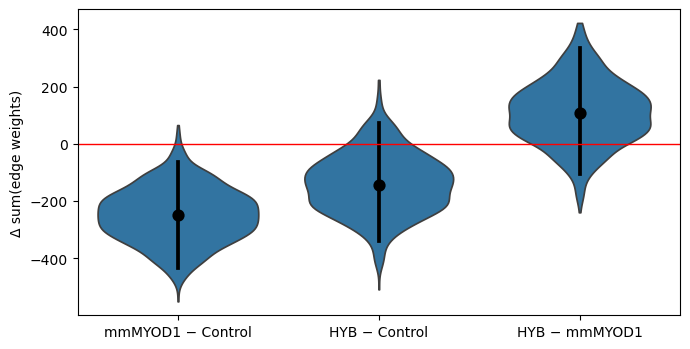

In [57]:
diff = pd.DataFrame({
    "mmMYOD1 − Control": boot_df[mmy] - boot_df[ctrl],
    "HYB − Control":     boot_df[hyb] - boot_df[ctrl],
    "HYB − mmMYOD1":     boot_df[hyb] - boot_df[mmy],
}).melt(var_name="contrast", value_name="delta_sumW")

plt.figure(figsize=(7, 3.6))
sns.violinplot(data=diff, x="contrast", y="delta_sumW", inner=None, cut=0)
sns.pointplot(
    data=diff, x="contrast", y="delta_sumW",
    estimator=np.median, errorbar=lambda x: (np.quantile(x, 0.025), np.quantile(x, 0.975)),
    join=False, color="black"
)
plt.axhline(0, color="red", linewidth=1)
plt.ylabel("Δ sum(edge weights)")
plt.xlabel("")
plt.tight_layout()
plt.show()

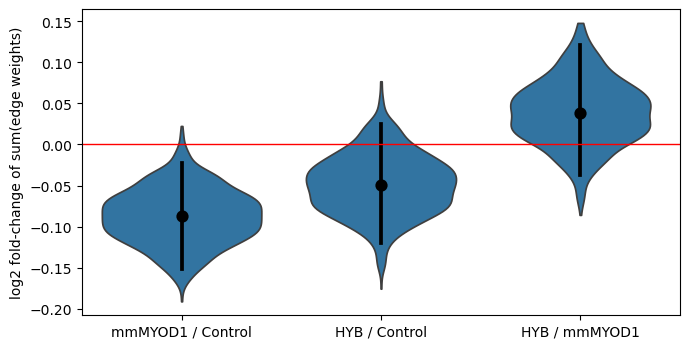

In [58]:
eps = 1e-12
log2fc = pd.DataFrame({
    "mmMYOD1 / Control": np.log2((boot_df[mmy] + eps) / (boot_df[ctrl] + eps)),
    "HYB / Control":     np.log2((boot_df[hyb] + eps) / (boot_df[ctrl] + eps)),
    "HYB / mmMYOD1":     np.log2((boot_df[hyb] + eps) / (boot_df[mmy] + eps)),
}).melt(var_name="contrast", value_name="log2FC_sumW")

plt.figure(figsize=(7, 3.6))
sns.violinplot(data=log2fc, x="contrast", y="log2FC_sumW", inner=None, cut=0)
sns.pointplot(
    data=log2fc, x="contrast", y="log2FC_sumW",
    estimator=np.median, errorbar=lambda x: (np.quantile(x, 0.025), np.quantile(x, 0.975)),
    join=False, color="black"
)
plt.axhline(0, color="red", linewidth=1)
plt.ylabel("log2 fold-change of sum(edge weights)")
plt.xlabel("")
plt.tight_layout()
plt.show()

In [60]:
%%time
phase = "G1S"
conds = [f"Control_{phase}", f"mmMYOD1_{phase}", f"siPRRX1/mmMYOD1_{phase}"]

boot_df1, info1, node_list1, edges1 = bootstrap_edge_weight_sums_fast_from_subG(
    adata=adata,
    subG=subG,     # <-- your precomputed union-filtered graph
    conds=conds,
    group_key="cond_phase_group",
    # layer_expr="CP10K",
    layer_expr='log_norm',
    layer_raw="raw_counts",
    min_pct=0.10,
    combine="product",
    n_boot=1000,
    frac=0.8,
    sample_mode="fixed_n_by_min",
    seed=1,
)

print(info1)
boot_df1.quantile([0.025, 0.5, 0.975])

{'n_nodes_used': 256, 'n_edges_used': 10036, 'group_sizes': {'Control_G1S': 4944, 'mmMYOD1_G1S': 2022, 'siPRRX1/mmMYOD1_G1S': 2885}, 'n_per_group': {'Control_G1S': 1617, 'mmMYOD1_G1S': 1617, 'siPRRX1/mmMYOD1_G1S': 1617}, 'sample_mode': 'fixed_n_by_min', 'frac': 0.8, 'min_pct': 0.1, 'combine': 'product', 'layers': ('log_norm', 'raw_counts')}
CPU times: user 3.02 s, sys: 639 ms, total: 3.66 s
Wall time: 3.71 s


,Control_G1S,mmMYOD1_G1S,siPRRX1/mmMYOD1_G1S
0.025,912.746973,989.402631,1226.391330
0.500,960.096710,1025.730347,1272.473999
0.975,1007.040633,1062.279361,1320.232779


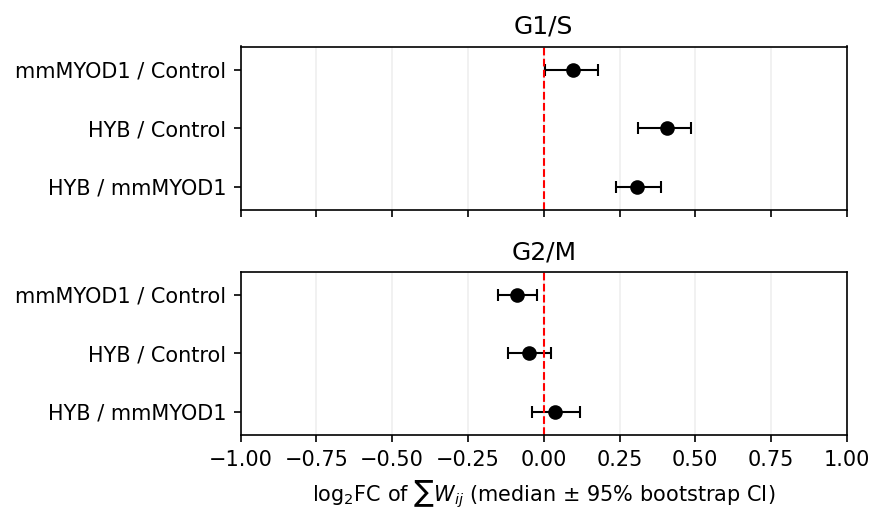

In [61]:
# combined plot
eps = 1e-12
ci_lo, ci_hi = 0.025, 0.975

# ---- Build bootstrap log2FC arrays ----
g1s_mmy_ctrl = np.log2((boot_df1["mmMYOD1_G1S"].to_numpy() + eps) / (boot_df1["Control_G1S"].to_numpy() + eps))
g1s_hyb_ctrl = np.log2((boot_df1["siPRRX1/mmMYOD1_G1S"].to_numpy() + eps) / (boot_df1["Control_G1S"].to_numpy() + eps))
g1s_hyb_mmy  = np.log2((boot_df1["siPRRX1/mmMYOD1_G1S"].to_numpy() + eps) / (boot_df1["mmMYOD1_G1S"].to_numpy() + eps))

g2m_mmy_ctrl = np.log2((boot_df["mmMYOD1_G2M"].to_numpy() + eps) / (boot_df["Control_G2M"].to_numpy() + eps))
g2m_hyb_ctrl = np.log2((boot_df["siPRRX1/mmMYOD1_G2M"].to_numpy() + eps) / (boot_df["Control_G2M"].to_numpy() + eps))
g2m_hyb_mmy  = np.log2((boot_df["siPRRX1/mmMYOD1_G2M"].to_numpy() + eps) / (boot_df["mmMYOD1_G2M"].to_numpy() + eps))

# ---- Summarize to median + 95% CI ----
rows = []
for phase, name, arr in [
    ("G1/S", "mmMYOD1 / Control", g1s_mmy_ctrl),
    ("G1/S", "HYB / Control",     g1s_hyb_ctrl),
    ("G1/S", "HYB / mmMYOD1",     g1s_hyb_mmy),
    ("G2/M", "mmMYOD1 / Control", g2m_mmy_ctrl),
    ("G2/M", "HYB / Control",     g2m_hyb_ctrl),
    ("G2/M", "HYB / mmMYOD1",     g2m_hyb_mmy),
]:
    rows.append({
        "phase": phase,
        "contrast": name,
        "median": float(np.quantile(arr, 0.5)),
        "lo": float(np.quantile(arr, ci_lo)),
        "hi": float(np.quantile(arr, ci_hi)),
    })

sumdf = pd.DataFrame(rows)

# order within each panel
# contrast_order = ["mmMYOD1 / Control", "HYB / Control", "HYB / mmMYOD1"]
contrast_order = ["HYB / mmMYOD1", "HYB / Control", "mmMYOD1 / Control"]
sumdf["contrast"] = pd.Categorical(sumdf["contrast"], categories=contrast_order, ordered=True)


# ---- Forest plot (two panels) ----
fig, axes = plt.subplots(2, 1, figsize=(6, 3.6), sharex=True, dpi=150)

for ax, phase in zip(axes, ["G1/S", "G2/M"]):
    sub = sumdf[sumdf["phase"] == phase].sort_values("contrast")
    y = np.arange(len(sub))

    ax.errorbar(
        sub["median"], y,
        xerr=[sub["median"] - sub["lo"], sub["hi"] - sub["median"]],
        fmt="o", color="black", ecolor="black", capsize=3, lw=1
    )
    ax.axvline(0, color="red", lw=1, ls='--')
    ax.set_yticks(y)
    ax.set_yticklabels(sub["contrast"])
    ax.set_title(phase)
    ax.set_xlabel("log$_2$FC of $∑W_{ij}$ (median ± 95% bootstrap CI)")
    ax.grid(axis="x", alpha=0.2)
    ax.set_xlim(-1, 1)
    ax.margins(x=0.1, y=0.2)
    
    if phase == 'G1/S':
        ax.set_xlabel('')

axes[0].set_ylabel("")
# fig.suptitle("Network activity: bootstrap log2FC of sum(edge weights)", y=1.02)
fig.tight_layout()

plt.show()

# Normalize weights

In [62]:
def edges_as_index(G: nx.Graph) -> pd.MultiIndex:
    """Canonical undirected edge index (u < v) so graphs can be aligned."""
    pairs = []
    for u, v in G.edges():
        a, b = (u, v) if u <= v else (v, u)
        pairs.append((a, b))
    return pd.MultiIndex.from_tuples(pairs, names=["u", "v"])

def edge_weights_df(graphs: dict, weight_attr: str = "weight", fill_missing: float = 0.0) -> pd.DataFrame:
    """
    Return DataFrame of edge weights aligned by canonical edge index.
    graphs: dict[name -> nx.Graph]
    """
    # union of all edges (in case edge sets differ)
    all_edges = None
    for G in graphs.values():
        idx = edges_as_index(G)
        all_edges = idx if all_edges is None else all_edges.union(idx)

    out = pd.DataFrame(index=all_edges)
    for name, G in graphs.items():
        w = {}
        for u, v, d in G.edges(data=True):
            a, b = (u, v) if u <= v else (v, u)
            w[(a, b)] = float(d.get(weight_attr, fill_missing))
        out[name] = pd.Series(w, index=out.index, dtype=float).fillna(fill_missing)

    return out

def normalize_edge_mass(W: pd.Series, eps: float = 0.0) -> pd.Series:
    """
    Normalize weights so sum over edges = 1 (relative edge-mass).
    If eps>0, adds eps to denominator only (not to each edge).
    """
    denom = float(W.sum()) + float(eps)
    if denom == 0.0:
        return W.copy()  # all zeros
    return W / denom

def diff_edges(W_norm: pd.Series, B_norm: pd.Series, eps: float = 1e-12):
    """
    Compute delta and log-ratio for normalized edge weights.
    Returns DataFrame with columns: delta, logfc
    """
    delta = W_norm - B_norm
    logfc = np.log((W_norm + eps) / (B_norm + eps))
    return pd.DataFrame({"delta": delta, "logfc": logfc})

def top_edges(diff: pd.DataFrame, k: int = 25, score: str = "abs_delta") -> pd.DataFrame:
    """
    Rank edges by a score and return top-k.
    score: 'abs_delta' or 'abs_logfc'
    """
    if score == "abs_delta":
        s = diff["delta"].abs()
    elif score == "abs_logfc":
        s = diff["logfc"].abs()
    else:
        raise ValueError("score must be 'abs_delta' or 'abs_logfc'")
    return diff.assign(score=s).sort_values("score", ascending=False).head(k)

def attach_edge_attr_from_series(G: nx.Graph, s: pd.Series, attr: str, fill_missing: float = 0.0) -> nx.Graph:
    """Attach an edge attribute (aligned by canonical undirected edge key) to a copy of G."""
    H = G.copy()
    for u, v in H.edges():
        a, b = (u, v) if u <= v else (v, u)
        H[u][v][attr] = float(s.get((a, b), fill_missing))
    return H

In [63]:
graphs = {
    "Control": wCGM,
    "mmMYOD1": wMGM,
    "HYB": wHGM
}

# 1) Align all edge weights into a single table
W = edge_weights_df(graphs, weight_attr="weight", fill_missing=0.0)
# W columns = ["Control","mmMYOD1","HYB"], index = (u,v) MultiIndex

# 2) Edge-mass normalize within each group (relative rewiring)
W_norm = W.apply(lambda col: normalize_edge_mass(col, eps=0.0), axis=0)

# Quick sanity: each column should sum to 1 (or 0 if graph had all-zero weights)
print("Normalized edge-mass sums:\n", W_norm.sum(axis=0))

Normalized edge-mass sums:
 Control    1.0
mmMYOD1    1.0
HYB        1.0
dtype: float64


In [97]:
print(W_norm.shape)
W_norm.head()

(10036, 3)


,,Control,mmMYOD1,HYB
u,v,,,
HDAC1,RCC1,0.000006,0.000009,0.000006
CDCA8,RCC1,0.000008,0.000017,0.000013
CDC20,RCC1,0.000004,0.000011,0.000008
KIF2C,RCC1,0.000007,0.000011,0.000009
NASP,RCC1,0.000037,0.000129,0.000090


In [64]:
# 3) Differential edges vs Control (within this phase)
diff_m = diff_edges(W_norm["mmMYOD1"], W_norm["Control"], eps=1e-12)
diff_h = diff_edges(W_norm["HYB"],     W_norm["Control"], eps=1e-12)

diff_t = diff_edges(W_norm["HYB"],     W_norm["mmMYOD1"], eps=1e-12)

# 4) Top differential edges
top_m = top_edges(diff_m, k=30, score="abs_delta")
top_h = top_edges(diff_h, k=30, score="abs_delta")

print("\nTop edges: mmMYOD1 vs Control (by |delta|)")
print(top_m.head(10))

print("\nTop edges: HYB vs Control (by |delta|)")
print(top_h.head(10))


Top edges: mmMYOD1 vs Control (by |delta|)
                     delta     logfc     score
u        v                                    
RBX1     RPS6    -0.015002 -0.749551  0.015002
RPS6     YWHAB   -0.012755 -0.642520  0.012755
EIF4EBP1 RPS6    -0.009627 -1.101173  0.009627
ITGB1    YWHAB   -0.009559 -1.496478  0.009559
CALM1    CALM2   -0.009075 -0.442912  0.009075
ITGB1    SKP1    -0.009038 -1.368658  0.009038
APP      ITGB1   -0.008397 -2.560514  0.008397
CALM2    RBX1    -0.008087 -0.687684  0.008087
CCND1    GADD45A  0.007308  3.336863  0.007308
GADD45A  SKP1     0.006972  2.403147  0.006972

Top edges: HYB vs Control (by |delta|)
                   delta     logfc     score
u        v                                  
RBX1     RPS6  -0.013201 -0.623810  0.013201
RPS6     YWHAB -0.012476 -0.622984  0.012476
EIF4EBP1 RPS6  -0.010731 -1.362763  0.010731
ITGB1    YWHAB -0.008402 -1.146208  0.008402
CALM1    CALM2 -0.008138 -0.386942  0.008138
APP      ITGB1 -0.008041 -2.151065  0

In [65]:
def node_strength_from_edge_series(edge_s: pd.Series) -> pd.Series:
    """Compute node strengths from an edge series indexed by (u,v)."""
    strength = {}
    for (u, v), w in edge_s.items():
        strength[u] = strength.get(u, 0.0) + float(w)
        strength[v] = strength.get(v, 0.0) + float(w)
    return pd.Series(strength, dtype=float)

delta_strength_m = node_strength_from_edge_series(diff_m["delta"]).sort_values(ascending=False)
delta_strength_h = node_strength_from_edge_series(diff_h["delta"]).sort_values(ascending=False)

delta_strength_t = node_strength_from_edge_series(diff_t["delta"]).sort_values(ascending=False)

print("\nTop genes gaining relative edge-mass (mmMYOD1 vs Control):")
print(delta_strength_m.head(10))

print("\nTop genes gaining relative edge-mass (HYB vs Control):")
print(delta_strength_h.head(10))

print("\nTop genes gaining relative edge-mass (HYB vs mmMYOD1):")
print(delta_strength_t.head(10))


Top genes gaining relative edge-mass (mmMYOD1 vs Control):
GADD45A    0.060241
CCND1      0.036544
GMNN       0.032823
MYC        0.030042
CDKN1A     0.024638
PLK2       0.021997
MDM2       0.018615
CDK6       0.014311
NASP       0.010999
GSK3B      0.008137
dtype: float64

Top genes gaining relative edge-mass (HYB vs Control):
GMNN       0.039170
GADD45A    0.026570
CDKN1A     0.025451
MDM2       0.021849
CCND1      0.019462
PTTG1      0.014709
PLK2       0.013566
NASP       0.013405
MYC        0.008179
SMC4       0.006428
dtype: float64

Top genes gaining relative edge-mass (HYB vs mmMYOD1):
HSPA8    0.015308
PTTG1    0.014845
SKP1     0.009010
CALM1    0.008925
ITGB1    0.007346
RBX1     0.006694
TOP2A    0.006448
GMNN     0.006347
CALM3    0.006001
MKI67    0.004360
dtype: float64


In [66]:
print(W_norm.shape)

# drop edges that are 0 across all groups
wdf = W_norm[(W_norm != 0).any(axis=1)].copy()
print(wdf.shape)
wdf.head()

(10036, 3)
(9484, 3)


,,Control,mmMYOD1,HYB
u,v,,,
HDAC1,RCC1,0.000006,0.000009,0.000006
CDCA8,RCC1,0.000008,0.000015,0.000012
CDC20,RCC1,0.000003,0.000011,0.000008
KIF2C,RCC1,0.000006,0.000011,0.000009
NASP,RCC1,0.000037,0.000130,0.000090


In [67]:
eps = 1e-12

wdf['logfc_mc'] = np.log2((wdf['mmMYOD1'] + eps) / (wdf['Control'] + eps))
wdf['logfc_hc'] = np.log2((wdf['HYB'] + eps) / (wdf['Control'] + eps))
wdf['logfc_hm'] = np.log2((wdf['HYB'] + eps) / (wdf['mmMYOD1'] + eps))

display(wdf.head())

wdf[['logfc_mc', 'logfc_hc', 'logfc_hm']].describe()

,,Control,mmMYOD1,HYB,logfc_mc,logfc_hc,logfc_hm
u,v,,,,,,
HDAC1,RCC1,0.000006,0.000009,0.000006,0.429379,-0.036248,-0.465627
CDCA8,RCC1,0.000008,0.000015,0.000012,0.966029,0.595282,-0.370747
CDC20,RCC1,0.000003,0.000011,0.000008,1.655471,1.186161,-0.469311
KIF2C,RCC1,0.000006,0.000011,0.000009,0.783570,0.563107,-0.220463
NASP,RCC1,0.000037,0.000130,0.000090,1.808910,1.284745,-0.524165


,logfc_mc,logfc_hc,logfc_hm
count,9484.000000,9484.000000,9484.000000
mean,0.513332,2.497171,1.983839
std,9.693802,8.495198,6.934002
min,-29.208060,-26.439859,-27.595725
25%,-0.449254,-0.131194,-0.324114
50%,0.275684,0.437292,0.064872
75%,1.358277,1.272857,0.475627
max,28.839612,27.521546,27.957912


# Centrality

In [68]:
# --- MYOD1 ---
deg1 = dict(wMGM.degree(weight='weight'))
clust1 = nx.clustering(wMGM, weight='weight')
eig1 = nx.eigenvector_centrality(wMGM, weight='weight')
# distance = 1/w --> algorithm interprets high weight as high distance, thus we took the inverse
# (Small distance = High importance)
betw1 = nx.betweenness_centrality(wMGM, weight='distance') 
close1 = nx.closeness_centrality(wMGM, distance='distance')

# weight='weight' uses your activity product (au * av)
pagerank1 = nx.pagerank(wMGM, weight='weight') 

df1 = pd.DataFrame({
    "strength": pd.Series(deg1),
    "clustering": pd.Series(clust1),
    "eigenvector": pd.Series(eig1),
    "pagerank": pd.Series(pagerank1),
    "betweenness": pd.Series(betw1),
    "closeness": pd.Series(close1),
})

# df1 = df1.reset_index(names='gene_name')

display(df1.head())

# --- Control ---
deg2 = dict(wCGM.degree(weight='weight'))
clust2 = nx.clustering(wCGM, weight='weight')
eig2 = nx.eigenvector_centrality(wCGM, weight='weight')

betw2 = nx.betweenness_centrality(wCGM, weight='distance')
close2 = nx.closeness_centrality(wCGM, distance='distance')

pagerank2 = nx.pagerank(wCGM, weight='weight') 

df2 = pd.DataFrame({
    "strength": pd.Series(deg2),
    "clustering": pd.Series(clust2),
    "eigenvector": pd.Series(eig2),
    "pagerank": pd.Series(pagerank2),
    "betweenness": pd.Series(betw2),
    "closeness": pd.Series(close2),
})

# df2 = df2.reset_index(names='gene_name')

display(df2.head())


# --- HYB ---
deg3 = dict(wHGM.degree(weight='weight'))
clust3 = nx.clustering(wHGM, weight='weight')
eig3 = nx.eigenvector_centrality(wHGM, weight='weight')

betw3 = nx.betweenness_centrality(wHGM, weight='distance')
close3 = nx.closeness_centrality(wHGM, distance='distance')

pagerank3 = nx.pagerank(wHGM, weight='weight') 

df3 = pd.DataFrame({
    "strength": pd.Series(deg3),
    "clustering": pd.Series(clust3),
    "eigenvector": pd.Series(eig3),
    "pagerank": pd.Series(pagerank3),
    "betweenness": pd.Series(betw3),
    "closeness": pd.Series(close3),
})

# df3 = df3.reset_index(names='gene_name')

display(df3.head())

,strength,clustering,eigenvector,pagerank,betweenness,closeness
RCC1,9.827952,0.001194,0.003520,0.001357,3.393241e-07,1.581274e-08
KHDRBS1,32.549726,0.007393,0.038041,0.002648,0.000000e+00,1.581274e-08
HDAC1,15.745403,0.000886,0.004006,0.001850,0.000000e+00,1.581274e-08
CDCA8,21.680436,0.001148,0.001831,0.002467,9.768691e-06,1.581274e-08
CDC20,28.228845,0.000796,0.006042,0.002986,4.105653e-05,1.581274e-08


,strength,clustering,eigenvector,pagerank,betweenness,closeness
RCC1,4.386478,0.000402,0.000712,0.001004,3.393241e-07,1.100017e-08
KHDRBS1,34.638557,0.002808,0.029552,0.002759,0.000000e+00,1.100017e-08
HDAC1,22.252619,0.000535,0.003410,0.002512,1.715472e-06,1.100017e-08
CDCA8,21.611644,0.000675,0.000755,0.002682,2.480803e-05,1.100017e-08
CDC20,15.026435,0.000288,0.001729,0.002118,6.468301e-05,1.100017e-08


,strength,clustering,eigenvector,pagerank,betweenness,closeness
RCC1,8.771504,0.000987,0.002376,0.001155,0.000000e+00,2.530039e-08
KHDRBS1,33.530614,0.005166,0.028307,0.002358,0.000000e+00,2.530039e-08
HDAC1,18.094608,0.000807,0.003157,0.001817,0.000000e+00,2.530039e-08
CDCA8,30.558730,0.001345,0.001870,0.002730,9.851710e-07,2.530039e-08
CDC20,33.902299,0.000813,0.004826,0.003009,1.727601e-05,2.530039e-08


In [69]:
# print(f'{phase}')

## M + H
print("mmMYOD1 and HYB:")
common_genes = df1.index.intersection(df3.index)
s_corr, p_value = spearmanr(df1.loc[common_genes, 'strength'], 
                            df3.loc[common_genes, 'strength'])

print(f"\tSpearman Correlation: {s_corr:.3f} (p={p_value:.3e})")

k_corr, p_value = kendalltau(df1.loc[common_genes, 'strength'], 
                            df3.loc[common_genes, 'strength'])

print(f"\tKendall tau: {k_corr:.3f} (p={p_value:.3e})\n")


## M + C
print("mmMYOD1 and Control:")
common_genes = df1.index.intersection(df2.index)
s_corr, p_value = spearmanr(df1.loc[common_genes, 'strength'], 
                            df2.loc[common_genes, 'strength'])

print(f"\tSpearman Correlation: {s_corr:.3f} (p={p_value:.3e})")

k_corr, p_value = kendalltau(df1.loc[common_genes, 'strength'], 
                            df2.loc[common_genes, 'strength'])

print(f"\tKendall tau: {k_corr:.3f} (p={p_value:.3e})\n")


## H + C
print("HYB and Control:")
common_genes = df3.index.intersection(df2.index)
s_corr, p_value = spearmanr(df3.loc[common_genes, 'strength'], 
                            df2.loc[common_genes, 'strength'])

print(f"\tSpearman Correlation: {s_corr:.3f} (p={p_value:.3e})")

k_corr, p_value = kendalltau(df3.loc[common_genes, 'strength'], 
                            df2.loc[common_genes, 'strength'])

print(f"\tKendall tau: {k_corr:.3f} (p={p_value:.3e})\n")

mmMYOD1 and HYB:
	Spearman Correlation: 0.964 (p=8.564e-148)
	Kendall tau: 0.850 (p=7.427e-91)

mmMYOD1 and Control:
	Spearman Correlation: 0.883 (p=2.014e-85)
	Kendall tau: 0.711 (p=8.728e-64)

HYB and Control:
	Spearman Correlation: 0.928 (p=1.275e-110)
	Kendall tau: 0.776 (p=9.265e-76)



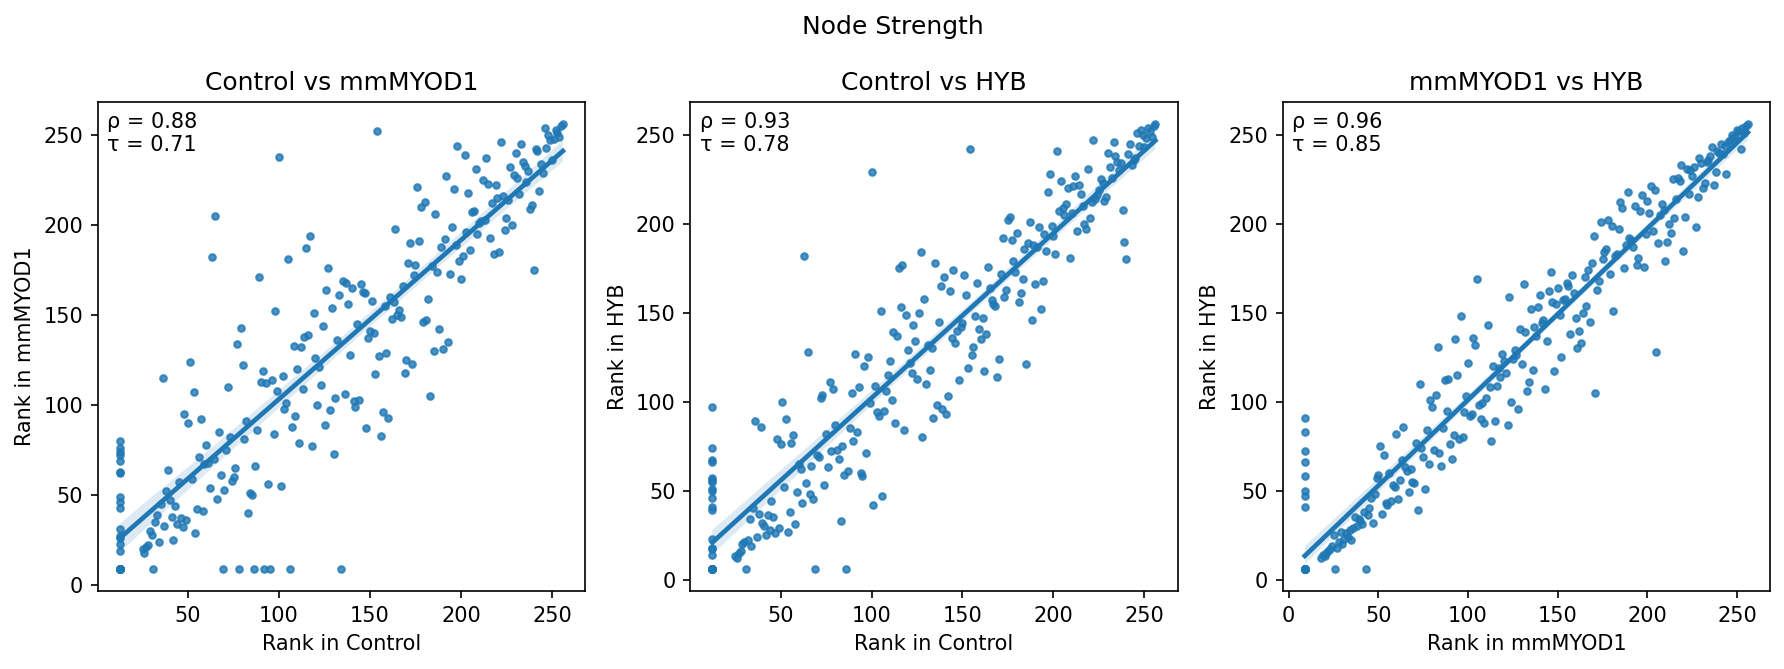

In [70]:
conds_dfs = {
    'Control': df2,
    'mmMYOD1': df1,
    'HYB': df3,
}

pairs = list(combinations(conds_dfs.items(), 2))


fig, axes = plt.subplots(1, len(pairs), figsize=(12, 4.5), dpi=150)

for ax, ((name1, df_a), (name2, df_b)) in zip(axes, pairs):
    
    # Align indices to avoid mismatches
    common = df_a.index.intersection(df_b.index)
    x = df_a.loc[common, 'strength'].rank()
    y = df_b.loc[common, 'strength'].rank()
    
    # Spearman correlation
    s_corr, _ = spearmanr(x, y)
    k_tau, _ = kendalltau(x, y)
    
    sns.regplot(
        x=x, 
        y=y, 
        ax=ax, 
        scatter_kws={'s': 10},
    )
    
    ax.set_xlabel(f'Rank in {name1}')
    ax.set_ylabel(f'Rank in {name2}')
    ax.set_title(f'{name1} vs {name2}')
    
    ax.text(
        0.02, 0.98,
        f'ρ = {s_corr:.2f}\nτ = {k_tau:.2f}',
        transform=ax.transAxes,   # key: use axis coordinates (0–1)
        ha='left',
        va='top',
        fontsize=10
    )

plt.suptitle('Node Strength')
plt.tight_layout()
plt.show()

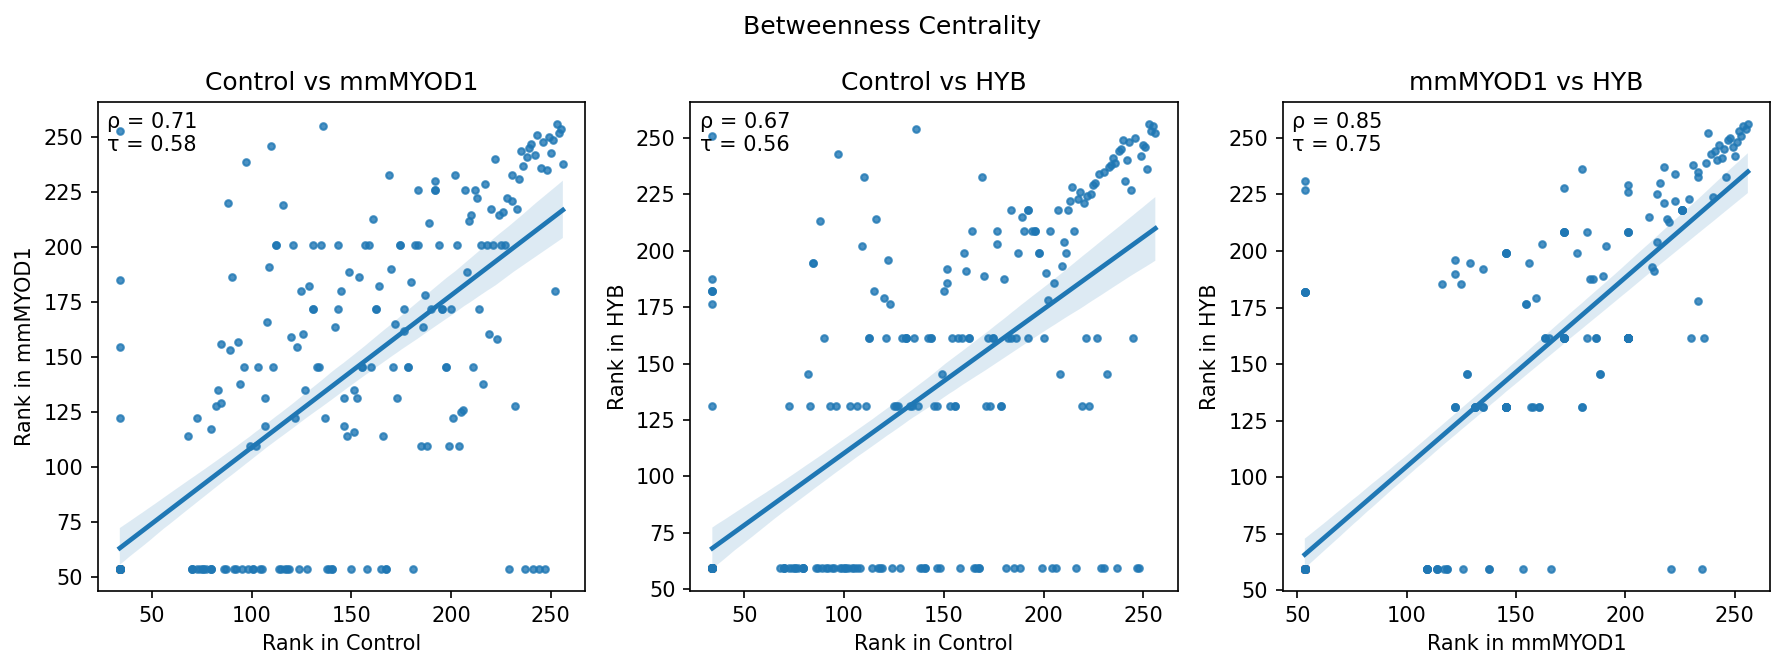

In [71]:
conds_dfs = {
    'Control': df2,
    'mmMYOD1': df1,
    'HYB': df3,
}

pairs = list(combinations(conds_dfs.items(), 2))


fig, axes = plt.subplots(1, len(pairs), figsize=(12, 4.5), dpi=150)

for ax, ((name1, df_a), (name2, df_b)) in zip(axes, pairs):
    
    # Align indices to avoid mismatches
    common = df_a.index.intersection(df_b.index)
    x = df_a.loc[common, 'betweenness'].rank()
    y = df_b.loc[common, 'betweenness'].rank()
    
    # Spearman correlation
    s_corr, _ = spearmanr(x, y)
    k_tau, _ = kendalltau(x, y)
    
    sns.regplot(
        x=x, 
        y=y, 
        ax=ax, 
        scatter_kws={'s': 10},
    )
    
    ax.set_xlabel(f'Rank in {name1}')
    ax.set_ylabel(f'Rank in {name2}')
    ax.set_title(f'{name1} vs {name2}')
    
    ax.text(
        0.02, 0.98,
        f'ρ = {s_corr:.2f}\nτ = {k_tau:.2f}',
        transform=ax.transAxes,   # key: use axis coordinates (0–1)
        ha='left',
        va='top',
        fontsize=10
    )

plt.suptitle('Betweenness Centrality')
plt.tight_layout()
plt.show()

In [72]:
conds_dfs = {
    'Control': df2,
    'mmMYOD1': df1,
    'HYB': df3,
}

metrics = ['strength', 'pagerank', 'betweenness']

rows = []

for (name1, df_a), (name2, df_b) in combinations(conds_dfs.items(), 2):
    
    common = df_a.index.intersection(df_b.index)
    
    row = {'comparison': f'{name1} vs {name2}'}
    
    for metric in metrics:
        x = df_a.loc[common, metric]
        y = df_b.loc[common, metric]
        
        s_corr, _ = spearmanr(x, y)
        k_corr, _ = kendalltau(x, y)
        
        row[f'{metric}_spearman'] = s_corr
        row[f'{metric}_kendall'] = k_corr
    
    rows.append(row)

corr_df = pd.DataFrame(rows).set_index('comparison')

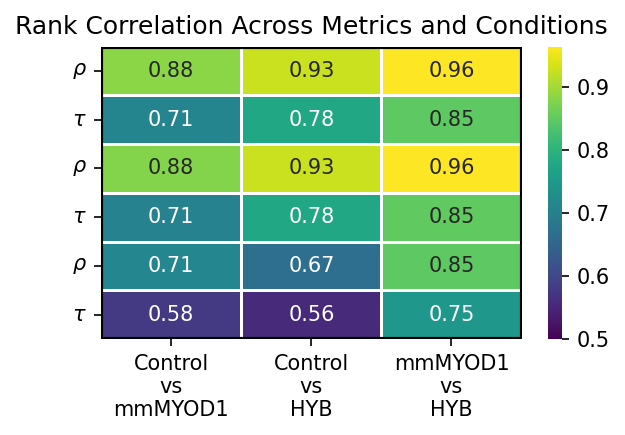

In [73]:
plt.figure(figsize=(4, 3), dpi=150)

sns.heatmap(
    corr_df.T,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0.5,
    # center=0,
    linewidths=0.5,
    # cbar_kws={'label': 'correlation'},
)

ax = plt.gca()
n_rows, n_cols = corr_df.T.shape
rect = patches.Rectangle(
    (0, 0), n_cols, n_rows,
    linewidth=2, edgecolor='black', facecolor='none', zorder=10
)
ax.add_patch(rect)


xticks = corr_df.T.columns  # since you're plotting corr_df.T
new_xticklabels = [label.replace(' vs ', '\nvs\n') for label in xticks]
ax.set_xticklabels(new_xticklabels, rotation=0)

yticks = corr_df.T.index
new_yticklabels = ['$ρ$' if 'spearman' in label else '$τ$' for label in yticks]
ax.set_yticklabels(new_yticklabels, rotation=0)

plt.title("Rank Correlation Across Metrics and Conditions")
plt.xlabel('')
plt.tight_layout()
plt.show()

In [110]:
# Compare betweenness shifts specifically
betw_comp = pd.DataFrame({
    'Ctrl_Betw': df2['betweenness']/df2['betweenness'].max(),
    'MYOD1_Betw': df1['betweenness']/df1['betweenness'].max()
})

display(betw_comp[['Ctrl_Betw', 'MYOD1_Betw']].describe())


betw_comp['Delta_Betw'] = betw_comp['MYOD1_Betw'] - betw_comp['Ctrl_Betw']

print("Genes that became major bottlenecks in mmMYOD1:")
print(betw_comp.sort_values('Delta_Betw', ascending=False).head(20))

,Ctrl_Betw,MYOD1_Betw
count,256.000000,256.000000
mean,0.022629,0.021202
std,0.110643,0.111562
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000016,0.000003
75%,0.000062,0.000021
max,1.000000,1.000000


Genes that became major bottlenecks in mmMYOD1:
         Ctrl_Betw  MYOD1_Betw  Delta_Betw
GMNN      0.000017    0.906670    0.906653
GADD45A   0.000000    0.593537    0.593537
SKP1      0.421556    1.000000    0.578444
CCND1     0.110925    0.459989    0.349063
PLK2      0.000005    0.081767    0.081762
MYC       0.000618    0.035782    0.035164
MDM2      0.000005    0.033069    0.033064
YWHAB     0.208297    0.233338    0.025041
NASP      0.048530    0.067376    0.018846
MAD1L1    0.000039    0.016631    0.016592
TERF1     0.000086    0.016632    0.016547
MNAT1     0.033646    0.043315    0.009669
AURKA     0.000062    0.006922    0.006860
RBBP8     0.000021    0.005591    0.005570
CDK6      0.000261    0.005156    0.004895
PTTG1     0.086018    0.089928    0.003909
CCNE2     0.000003    0.000045    0.000042
CCNB2     0.000051    0.000087    0.000036
CDKN3     0.000011    0.000042    0.000031
BUB1      0.000062    0.000087    0.000026


In [111]:
# Compare betweenness shifts specifically
betw_comp = pd.DataFrame({
    'Ctrl_Betw': df2['betweenness']/df2['betweenness'].max(),
    'HYB_Betw': df3['betweenness']/df3['betweenness'].max()
})

display(betw_comp[['Ctrl_Betw', 'HYB_Betw']].describe())


betw_comp['Delta_Betw'] = betw_comp['HYB_Betw'] - betw_comp['Ctrl_Betw']

print("Genes that became major bottlenecks in HYB:")
print(betw_comp.sort_values('Delta_Betw', ascending=False).head(20))

,Ctrl_Betw,HYB_Betw
count,256.000000,256.000000
mean,0.022629,0.018809
std,0.110643,0.100414
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000016,0.000000
75%,0.000062,0.000006
max,1.000000,1.000000


Genes that became major bottlenecks in HYB:
         Ctrl_Betw  HYB_Betw  Delta_Betw
GMNN      0.000017  0.608473    0.608456
SKP1      0.421556  1.000000    0.578444
GADD45A   0.000000  0.343748    0.343748
PTTG1     0.086018  0.160214    0.074196
CCND1     0.110925  0.158086    0.047161
HSPA8     0.159041  0.191915    0.032874
MDM2      0.000005  0.028793    0.028788
PLK2      0.000005  0.014368    0.014363
MAD1L1    0.000039  0.014368    0.014329
NASP      0.048530  0.058327    0.009797
CLSPN     0.000158  0.002066    0.001908
CCNE2     0.000003  0.000016    0.000012
CDKN3     0.000011  0.000019    0.000007
CCNH      0.000002  0.000008    0.000006
CDK7      0.000002  0.000008    0.000006
RBL2      0.000000  0.000003    0.000003
CDC25B    0.000008  0.000009    0.000001
TFDP2     0.000000  0.000000    0.000000
STAG1     0.000000  0.000000    0.000000
USP37     0.000000  0.000000    0.000000


In [112]:
# Compare betweenness shifts specifically
betw_comp = pd.DataFrame({
    'MYOD1_Betw': df1['betweenness']/df1['betweenness'].max(),
    'HYB_Betw': df3['betweenness']/df3['betweenness'].max()
})

display(betw_comp[['MYOD1_Betw', 'HYB_Betw']].describe())


betw_comp['Delta_Betw'] = betw_comp['HYB_Betw'] - betw_comp['MYOD1_Betw']

print("Genes that became major bottlenecks in HYB vs mmMYOD1:")
print(betw_comp.sort_values('Delta_Betw', ascending=False).head(20))

,MYOD1_Betw,HYB_Betw
count,256.000000,256.000000
mean,0.021202,0.018809
std,0.111562,0.100414
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000003,0.000000
75%,0.000021,0.000006
max,1.000000,1.000000


Genes that became major bottlenecks in HYB vs mmMYOD1:
         MYOD1_Betw  HYB_Betw  Delta_Betw
RBX1       0.031616  0.408803    0.377188
CALM2      0.674905  0.773704    0.098800
ITGB1      0.046602  0.140202    0.093600
PTTG1      0.089928  0.160214    0.070287
HSPA8      0.129552  0.191915    0.062363
TOP2A      0.000014  0.018872    0.018859
CDK4       0.000033  0.014437    0.014404
CDK1       0.000069  0.014444    0.014374
CDKN1A     0.002307  0.015062    0.012754
PRKDC      0.000000  0.009693    0.009693
ANLN       0.000021  0.003821    0.003800
CDKN2A     0.007223  0.009762    0.002538
CLSPN      0.000039  0.002066    0.002027
ANAPC11    0.000000  0.000912    0.000912
SMC4       0.027351  0.027825    0.000474
RRM2       0.000021  0.000138    0.000117
TP53       0.000056  0.000117    0.000061
MTA3       0.000000  0.000000    0.000000
ANAPC13    0.000000  0.000000    0.000000
GSK3B      0.000000  0.000000    0.000000


In [109]:
# Compare betweenness shifts specifically
betw_comp = pd.DataFrame({
    'Ctrl_Betw': df2['betweenness'],
    'MYOD1_Betw': df1['betweenness']
})

display(betw_comp[['Ctrl_Betw', 'MYOD1_Betw']].describe())


betw_comp['Delta_Betw'] = betw_comp['MYOD1_Betw'] - betw_comp['Ctrl_Betw']

print("Genes that became major bottlenecks in mmMYOD1:")
print(betw_comp.sort_values('Delta_Betw', ascending=False).head(20))

,Ctrl_Betw,MYOD1_Betw
count,256.000000,256.000000
mean,0.009563,0.009845
std,0.046573,0.051731
min,0.000000,0.000000
25%,0.000003,0.000000
50%,0.000033,0.000001
75%,0.000109,0.000011
max,0.438105,0.462344


Genes that became major bottlenecks in mmMYOD1:
         Ctrl_Betw  MYOD1_Betw  Delta_Betw
GMNN      0.000048    0.421895    0.421847
GADD45A   0.000017    0.268893    0.268876
SKP1      0.204932    0.462344    0.257412
CCND1     0.102712    0.216467    0.113755
YWHAB     0.067192    0.108723    0.041532
PLK2      0.000004    0.038197    0.038193
PTTG1     0.004816    0.041722    0.036906
MYC       0.000642    0.016811    0.016169
MDM2      0.000041    0.015474    0.015433
SMC4      0.000158    0.010595    0.010437
MAD1L1    0.000052    0.007815    0.007763
TERF1     0.000059    0.007783    0.007723
MNAT1     0.015442    0.022388    0.006945
AURKA     0.000105    0.003252    0.003147
RBBP8     0.000034    0.002596    0.002562
CDK6      0.000366    0.002454    0.002088
CALM1     0.021800    0.022356    0.000556
PPME1     0.007781    0.007812    0.000031
FBXL7     0.000000    0.000000    0.000000
CNOT6     0.000000    0.000000    0.000000


In [ ]:
### Single-cell version ? 

# Correlation

In [48]:
# subset for conditions of interest
phase = 'G1S'
# conds = [f'Control_{phase}', f'mmMYOD1_{phase}', f'siPRRX1/mmMYOD1_{phase}', f'siPRRX1_{phase}']
conds = [f'mmMYOD1_{phase}', f'siPRRX1/mmMYOD1_{phase}', f'siPRRX1_{phase}', f'Control_{phase}']

print(len(node_list))

fdata = adata[adata.obs['cond_phase_group'].isin(conds), node_list].copy()

fdata

256


AnnData object with n_obs × n_vars = 10682 × 256
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'phase_grouped', 'cond_phase_group'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_tot

In [49]:
### mean of normalized counts
func = 'mean'

aggdata = sc.get.aggregate(
    fdata,
    by='cond_phase_group',
    func=func,
    layer='CP10K',
)

aggdata.X = aggdata.layers[f'{func}'].copy()

X = aggdata.X if isinstance(aggdata.X, np.ndarray) else aggdata.X.toarray()

df = pd.DataFrame(X, index=aggdata.obs_names, columns=aggdata.var_names).T

df = df.reset_index()

print(df.shape)
df.head()

(256, 5)


,gene_name,Control_G1S,mmMYOD1_G1S,siPRRX1/mmMYOD1_G1S,siPRRX1_G1S
0,ABL1,0.185218,0.560033,0.415042,0.377064
1,AMBRA1,0.445718,0.606220,0.591255,0.549241
2,ANAPC1,0.074626,0.300156,0.248051,0.189401
3,ANAPC10,0.238939,0.411469,0.387018,0.330474
4,ANAPC11,3.605231,2.142687,2.817980,3.746444


Using log-norm expression...
(256, 4)


,mmMYOD1_G1S,siPRRX1/mmMYOD1_G1S,siPRRX1_G1S,Control_G1S
mmMYOD1_G1S,0.000000e+00,1.092446e-148,1.406975e-77,5.503150e-82
siPRRX1/mmMYOD1_G1S,1.092446e-148,0.000000e+00,4.116910e-108,1.205400e-89
siPRRX1_G1S,1.406975e-77,4.116910e-108,0.000000e+00,2.794680e-98
Control_G1S,5.503150e-82,1.205400e-89,2.794680e-98,0.000000e+00


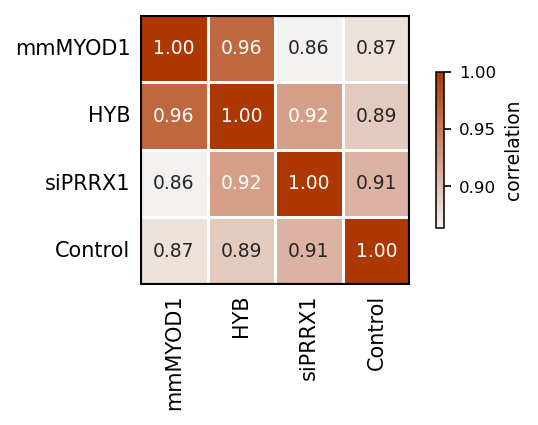

In [51]:
def correlation_heatmap(adata, dpi=200, figsize=(4, 4), cmap='magma', title='', label_map=None, zscore=False, cbar_label='correlation'):

    if zscore:
        print("Computing Z score...")
        # compute gene-wise Z score
        expr = adata.to_df().T
        A = expr.apply(scipy.stats.zscore, axis=1, result_type='expand')
        A.columns = expr.columns
        print(A.shape)
    else:
        print("Using log-norm expression...")
        A = adata.to_df().T
        print(A.shape)
    
    conditions = A.columns
    n = len(conditions)

    corrs = np.zeros((n, n))
    ps = np.zeros((n, n))

    for i, cond1 in enumerate(conditions):
        for j, cond2 in enumerate(conditions):
            # Compute Pearson correlation across all genes
            # corr, pval = pearsonr(A[cond1], A[cond2])
            corr, pval = spearmanr(A[cond1], A[cond2])
            corrs[i, j] = corr
            ps[i, j] = pval

    corr_df = pd.DataFrame(corrs, index=conditions, columns=conditions)
    pval_df = pd.DataFrame(ps, index=conditions, columns=conditions)

    display(pval_df)

    plt.rcParams['figure.dpi'] = dpi
    plt.figure(figsize=figsize)

    sns.heatmap(
        corr_df,
        cmap=cmap,
        square=True,
        annot=True,
        annot_kws={'fontsize':9},
        fmt=".2f",
        lw=0.5,
        linecolor='white',
        cbar_kws={'label':cbar_label, 'shrink': 0.45, 'pad': 0.075, 'format': '%.2f'},
    )
    
    plt.xlabel("")
    plt.ylabel("")
    plt.title(title)
    
    ax = plt.gca()
    
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=8)
    for spine in cbar.ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.75)
    cbar.set_label(cbar_label, fontsize=9)
    
    xticklabels = [label_map.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]
    yticklabels = [label_map.get(label.get_text(), label.get_text()) for label in ax.get_yticklabels()]
    ax.set_xticklabels(xticklabels, rotation=90, fontsize=10)
    ax.set_yticklabels(yticklabels, rotation=0, fontsize=10)
    ax.tick_params(axis='both', pad=1, bottom=False, left=False)
        
    n_rows, n_cols = corr_df.shape
    rect = patches.Rectangle(
        (0, 0), n_cols, n_rows,
        linewidth=2, edgecolor='black', facecolor='none', zorder=10
    )
    ax.add_patch(rect)
    
    plt.show()
    
    return corr_df
    

label_map = {
    f'Control_{phase}': 'Control',
    f'mmMYOD1_{phase}': 'mmMYOD1',
    f'siPRRX1/mmMYOD1_{phase}': 'HYB',
    f'siPRRX1_{phase}': 'siPRRX1',
}

g1s_cmap = sns.light_palette("#ad3803", as_cmap=True)
g2m_cmap = sns.light_palette("#56b567", as_cmap=True)


aggdata.X = aggdata.layers[f'{func}'].copy()

aggdata = aggdata[conds, :].copy()

corr_df = correlation_heatmap(aggdata, title='', cmap=g1s_cmap, label_map=label_map, dpi=150, figsize=(3, 3))

# corr_df = correlation_heatmap(aggdata, title='', cmap=g2m_cmap, label_map=label_map, dpi=150, figsize=(3, 3))


# corr_df1 = correlation_heatmap(g2m_gdata, title='', cmap=g2m_cmap, label_map=g2m_label_map, dpi=300, figsize=(3, 3))
# corr_df2 = correlation_heatmap(ccdata, title='', cmap='Blues', label_map=condition_label_map, dpi=300, figsize=(3, 3))

In [32]:
# fdata.X = fdata.layers['log_norm'].copy()

corr_method = 'spearman'

corr_matrices = {}

# conditions = ['Control', 'mmMYOD1', 'siPRRX1', 'siPRRX1/mmMYOD1']


for cond in conds:
    tmp = fdata[fdata.obs['cond_phase_group'] == cond, :].copy()
    print(tmp.shape)
    tmp.X = tmp.layers['log_norm'].copy()
    
    X = tmp.X if isinstance(tmp.X, np.ndarray) else tmp.X.toarray()

    X_df = pd.DataFrame(
        X,
        index=tmp.obs_names,
        columns=tmp.var_names,
    )

    RM = X_df.corr(method=corr_method)
    print(RM.shape)
    # display(RM.head())
    
    corr_matrices[cond] = RM

(3922, 256)
(256, 256)
(1924, 256)
(256, 256)
(2638, 256)
(256, 256)


# Gene scores

In [141]:
# subset for conditions of interest
phase = 'G2M'

conds = [f'Control_{phase}', f'mmMYOD1_{phase}', f'siPRRX1/mmMYOD1_{phase}']

fdata = adata[adata.obs['cond_phase_group'].isin(conds), :].copy()

fdata

AnnData object with n_obs × n_vars = 4129 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'phase_grouped', 'cond_phase_group'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_to

In [142]:
myo_genes = [
    'MYOD1', 'MYOG', 'MYH3', 'MYH8', 'MYH1', 'MYMK', 'DES', 
    'ACTA1', 'TNNT1', 'TNNT2', 'TNNT3', 'CKM', 'MEF2C', 'MYF6', 'MYF5',
    'SIX1', 'PAX3', 'PAX7', 'ENO3', 
]

myo_genes = [g for g in myo_genes if g in fdata.var_names]
print(len(myo_genes))
print(", ".join(myo_genes))


sc.tl.score_genes(
    fdata,
    gene_list = myo_genes,
    ctrl_size=50,
    score_name='myo_score',
    layer='log_norm',
)

13
MYOD1, MYH3, DES, ACTA1, TNNT1, TNNT2, CKM, MEF2C, MYF6, SIX1, PAX3, PAX7, ENO3
computing score 'myo_score'
    finished (0:00:00)


In [136]:
# from G1S (for same scale)
ymax = fdata.obs['myo_score'].max()
ymin = fdata.obs['myo_score'].min()

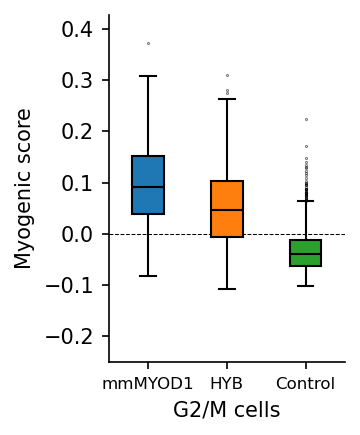

In [143]:
plt.figure(figsize=(2.5,3), dpi=150)

cond_order = [f'mmMYOD1_{phase}', f'siPRRX1/mmMYOD1_{phase}', f'Control_{phase}']

sns.boxplot(
    data=fdata.obs,
    x='cond_phase_group',
    hue='cond_phase_group',
    y='myo_score',
    order=cond_order,
    hue_order=cond_order,
    width=0.4,
    linecolor='k',
    linewidth=1,
    legend=False,
    saturation=1,
    flierprops={'markersize': 0.5, 'alpha': 0.5},
    zorder=1,
)


label_map = {
    f'mmMYOD1_{phase}': 'mmMYOD1',
    f'siPRRX1/mmMYOD1_{phase}': 'HYB',
    f'Control_{phase}': 'Control',
}

ax = plt.gca()
xticklabels = [label_map.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]
ax.set_xticklabels(xticklabels)#, rotation=90, fontsize=10)


plt.axhline(0, linestyle='--', linewidth=0.5, color='k', zorder=0)
plt.ylabel('Myogenic score')
plt.xticks(fontsize=8)

# plt.xlabel("G1/S cells")
plt.xlabel("G2/M cells")


plt.ylim(ymin-0.05, ymax+0.05)

sns.despine()
plt.tight_layout()
plt.show()

In [144]:
adata

AnnData object with n_obs × n_vars = 16296 × 25126
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'n_genes', 'doublet_score', 'predicted_doublet', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'phase_grouped', 'cond_phase_group'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_t

In [145]:
myo_genes = [
    'MYOD1', 'MYOG', 'MYH3', 'MYH8', 'MYH1', 'MYMK', 'DES', 
    'ACTA1', 'TNNT1', 'TNNT2', 'TNNT3', 'CKM', 'MEF2C', 'MYF6', 'MYF5',
    'SIX1', 'PAX3', 'PAX7', 'ENO3', 
]

myo_genes = [g for g in myo_genes if g in adata.var_names]
print(len(myo_genes))
print(", ".join(myo_genes))


fib_genes = [
    'PRRX1', 'TWIST1', 'TWIST2', 'DCN', 'VIM', 'PDGFRA', 'PDGFRB', 
    'COL1A1', 'COL1A2', 'FN1', 'FAP', 'THY1',
]

fib_genes = [g for g in fib_genes if g in adata.var_names]
print(len(fib_genes))
print(", ".join(fib_genes))


sc.tl.score_genes(
    adata,
    gene_list = myo_genes,
    ctrl_size=50,
    score_name='myo_score',
    layer='log_norm',
)

sc.tl.score_genes(
    adata,
    gene_list = fib_genes,
    ctrl_size=50,
    score_name='fib_score',
    layer='log_norm',
)

13
MYOD1, MYH3, DES, ACTA1, TNNT1, TNNT2, CKM, MEF2C, MYF6, SIX1, PAX3, PAX7, ENO3
12
PRRX1, TWIST1, TWIST2, DCN, VIM, PDGFRA, PDGFRB, COL1A1, COL1A2, FN1, FAP, THY1
computing score 'myo_score'
    finished (0:00:01)
computing score 'fib_score'
    finished (0:00:01)


In [147]:
df = adata.obs[['pooled_condition', 'cond_phase_group', 'phase', 'S_score', 'G2M_score', 'myo_score', 'fib_score']].copy()
df.head()

,pooled_condition,cond_phase_group,phase,S_score,G2M_score,myo_score,fib_score
AAACCAAAGCAACTGC_hybrid,siPRRX1/mmMYOD1,siPRRX1/mmMYOD1_G2M,G2M,-0.126850,4.600784,0.196562,0.224618
AAACCAAAGTAGGGCA_hybrid,mmMYOD1,mmMYOD1_G1S,S,0.393597,-0.038824,0.182773,0.100315
AAACCAAAGTCTAGGC_hybrid,siPRRX1/mmMYOD1,siPRRX1/mmMYOD1_G1S,G1,-0.779402,-1.776863,0.115066,0.691132
AAACCATTCACGTAAT_hybrid,siPRRX1,siPRRX1_G2M,G2M,0.471157,2.836471,-0.091618,0.514789
AAACCATTCAGGCAGA_hybrid,siPRRX1,siPRRX1_G2M,G2M,0.346421,4.170000,-0.036541,0.591335


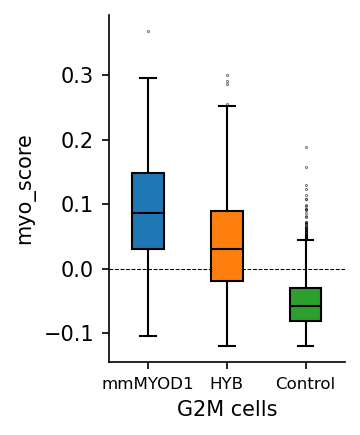

In [169]:
phase = 'G2M'
cond_order = [f'mmMYOD1_{phase}', f'siPRRX1/mmMYOD1_{phase}', f'Control_{phase}']

tmp = df[df['cond_phase_group'].isin(cond_order)].copy()

plt.figure(figsize=(2.5,3), dpi=150)

sns.boxplot(
    data=tmp,
    x='cond_phase_group',
    hue='cond_phase_group',
    y='myo_score',
    order=cond_order,
    hue_order=cond_order,
    width=0.4,
    linecolor='k',
    linewidth=1,
    legend=False,
    saturation=1,
    flierprops={'markersize': 0.5, 'alpha': 0.5},
    zorder=1,
)


label_map = {
    f'mmMYOD1_{phase}': 'mmMYOD1',
    f'siPRRX1/mmMYOD1_{phase}': 'HYB',
    f'Control_{phase}': 'Control',
}

ax = plt.gca()
xticklabels = [label_map.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]
ax.set_xticklabels(xticklabels)#, rotation=90, fontsize=10)


plt.axhline(0, linestyle='--', linewidth=0.5, color='k', zorder=0)
# plt.ylabel('Myogenic score')
plt.xticks(fontsize=8)

plt.xlabel(f"{phase} cells")
# plt.xlabel("G2/M cells")


# plt.ylim(ymin-0.05, ymax+0.05)

sns.despine()
plt.tight_layout()
plt.show()

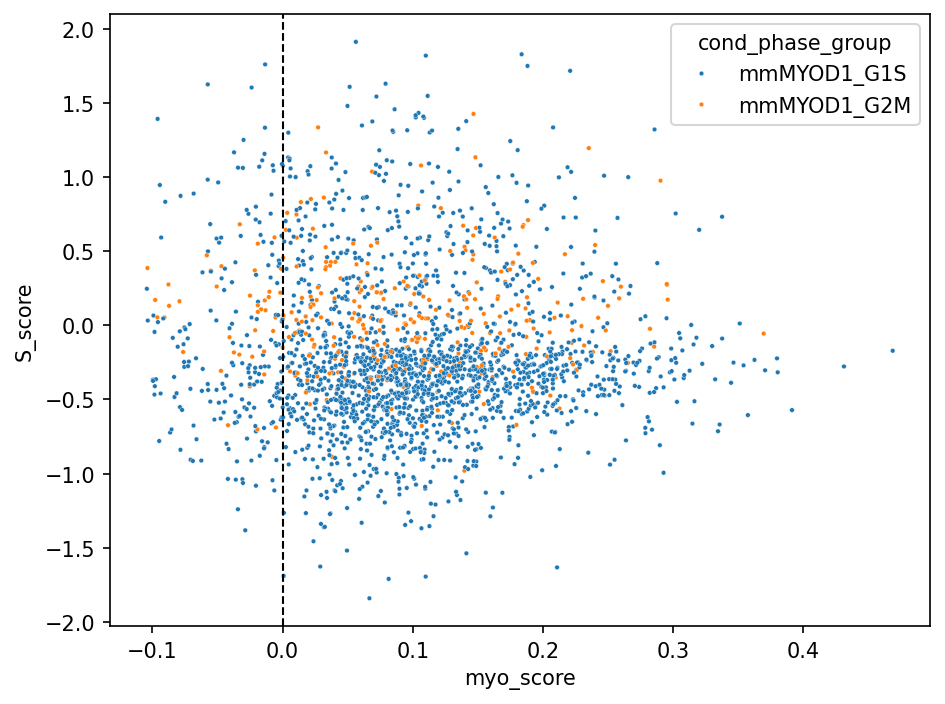

In [161]:
phase = 'G1S'

# conds = [f'mmMYOD1_{phase}', f'siPRRX1/mmMYOD1_{phase}']
# tmp = df[df['cond_phase_group'].isin(conds)].copy()


conds = ['mmMYOD1']#, 'siPRRX1/mmMYOD1']
tmp = df[df['pooled_condition'].isin(conds)].copy()

sns.scatterplot(
    data=tmp,
    x='myo_score',
    y='S_score',
    hue='cond_phase_group',
    s=5,
)

# sns.kdeplot(
#     data=tmp,
#     x='myo_score',
#     y='S_score',
#     hue='cond_phase_group',
#     fill=True,
#     # s=5,
# )


# sns.regplot(
#     data=df,
#     x='myo_score',
#     y='G2M_score',
#     hue='pooled_condition',
# )

plt.axvline(x=0, ls='--', color='k', lw=1)

plt.tight_layout()
plt.show()

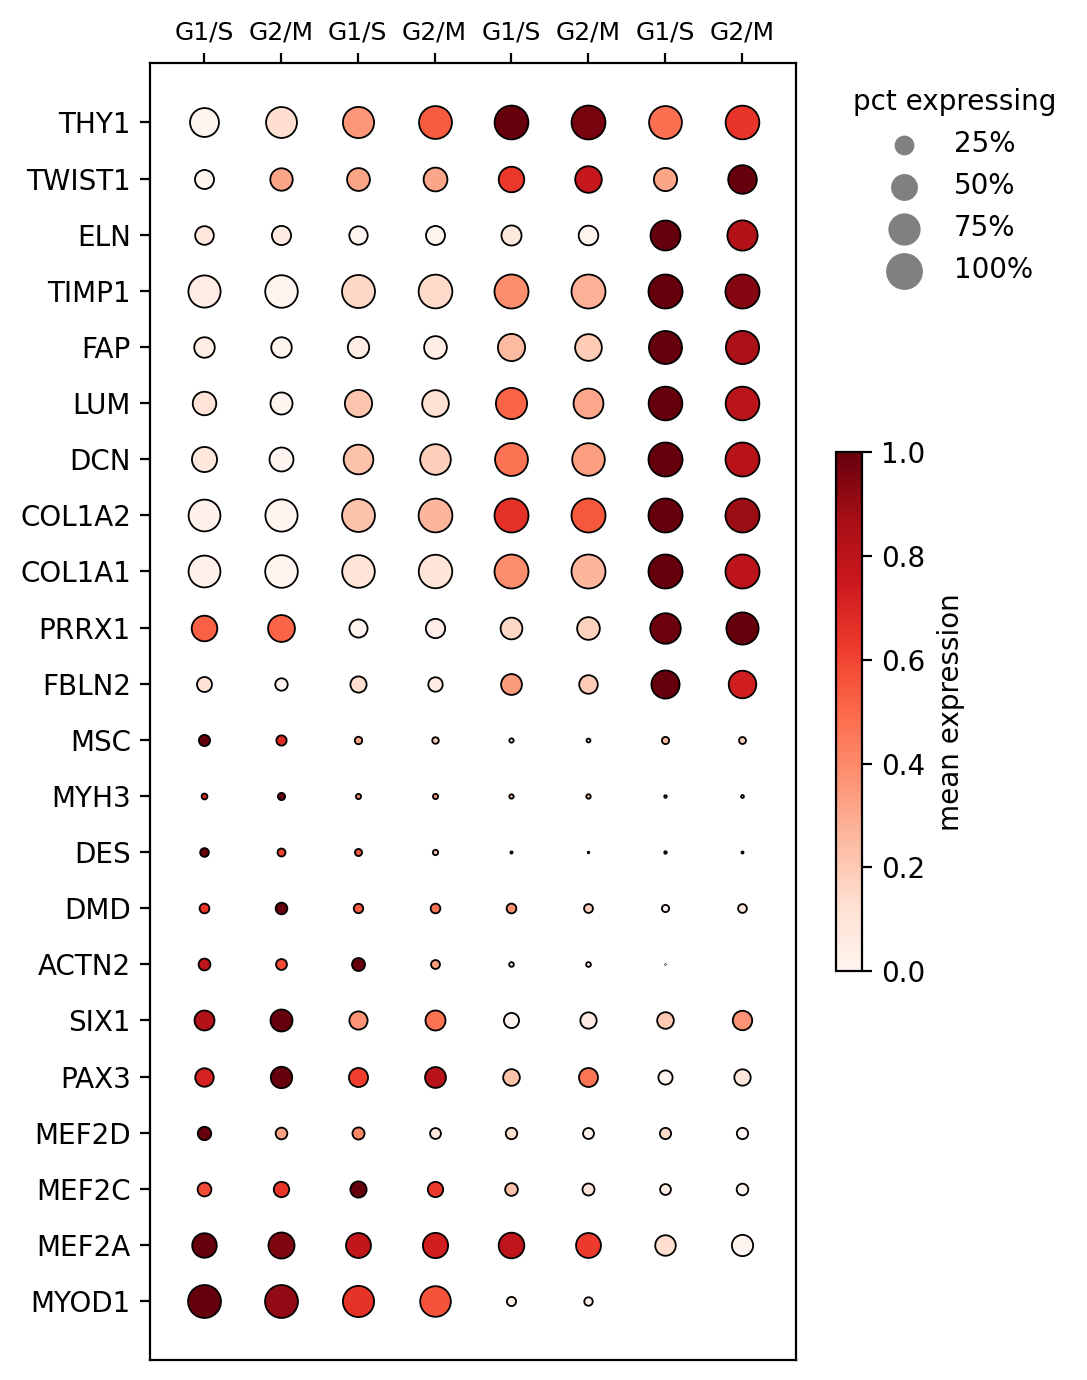

In [181]:
genes = [
    'MYOD1', 'MEF2A', 'MEF2C', 'MEF2D', 'PAX3', 'SIX1', 'ACTN2',
    'TNNT3', 'TNNI1', 'DMD', 'DES', 'MYH3', 'MSC', #'CKM', 'MYF6',# 'TTN', 'SOX8',
    'FBLN2',
    'PRRX1', 'COL1A1', 'COL1A2', 'DCN', 'LUM', 'FAP', 'TIMP1', 'ELN', 'TWIST1', 'THY1', 
]

genes_to_plot = [g for g in genes if g in adata.var_names]


groups = [
    'mmMYOD1_G1S', 'mmMYOD1_G2M',
    'siPRRX1/mmMYOD1_G1S', 'siPRRX1/mmMYOD1_G2M',
    'siPRRX1_G1S', 'siPRRX1_G2M',
    'Control_G1S', 'Control_G2M',
]
    

avg_expr = pd.DataFrame(index=genes_to_plot, columns=groups)
pct_expr = pd.DataFrame(index=genes_to_plot, columns=groups)

adata.X = adata.layers['log_norm'].copy()

for g in groups:
    # cells = adata.obs['leiden_split'] == g
    cells = adata.obs['cond_phase_group'] == g
    data = adata[cells, genes_to_plot].X
    # If sparse matrix
    if not isinstance(data, np.ndarray):
        data = data.toarray()
    avg_expr[g] = data.mean(axis=0)
    pct_expr[g] = (data > 0).mean(axis=0) * 100

    
avg_expr_scaled = (avg_expr.T - avg_expr.min(axis=1)) / (avg_expr.max(axis=1) - avg_expr.min(axis=1))
avg_expr_scaled = avg_expr_scaled.T
    
# # Z-score by gene
# avg_expr = avg_expr.T   
# avg_expr_z = avg_expr.apply(scipy.stats.zscore, axis=0)
# avg_expr_z = avg_expr_z.T

# print(avg_expr_z.shape)
# avg_expr_z.head()  

cmap = 'Reds'
size_scale = 1.5

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5.5, 7
fig, ax = plt.subplots()

for i, gene in enumerate(genes_to_plot):
    for j, cluster in enumerate(groups):
        size = float(pct_expr.loc[gene, cluster])*size_scale
        color = float(avg_expr_scaled.loc[gene, cluster])
        
        ax.scatter(
            x=j, 
            y=i, 
            s=size, 
            c=[color], 
            linewidths=0.65,
            edgecolors='k',
            cmap=cmap,
            vmin=0, 
            vmax=1, 
        )
        
ax.set_yticks(range(len(genes_to_plot)))
ax.set_yticklabels(genes_to_plot)

ax.set_xticks(range(len(groups)))

plot_labels = ['G1/S', 'G2/M'] * 4
ax.set_xticklabels(plot_labels, fontsize=9)#, rotation=90)

ax.xaxis.set_label_position('top') 
ax.xaxis.tick_top()
ax.set_xlabel('')

ax.margins(x=0.1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.05)
cbar.set_label('mean expression')


sizes = [25, 50, 75, 100]
markers = [plt.scatter([], [], s=s*size_scale, color='gray') for s in sizes]
labels = [f"{s}%" for s in sizes]

ax.legend(markers, labels, title="pct expressing", scatterpoints=1,
          frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()

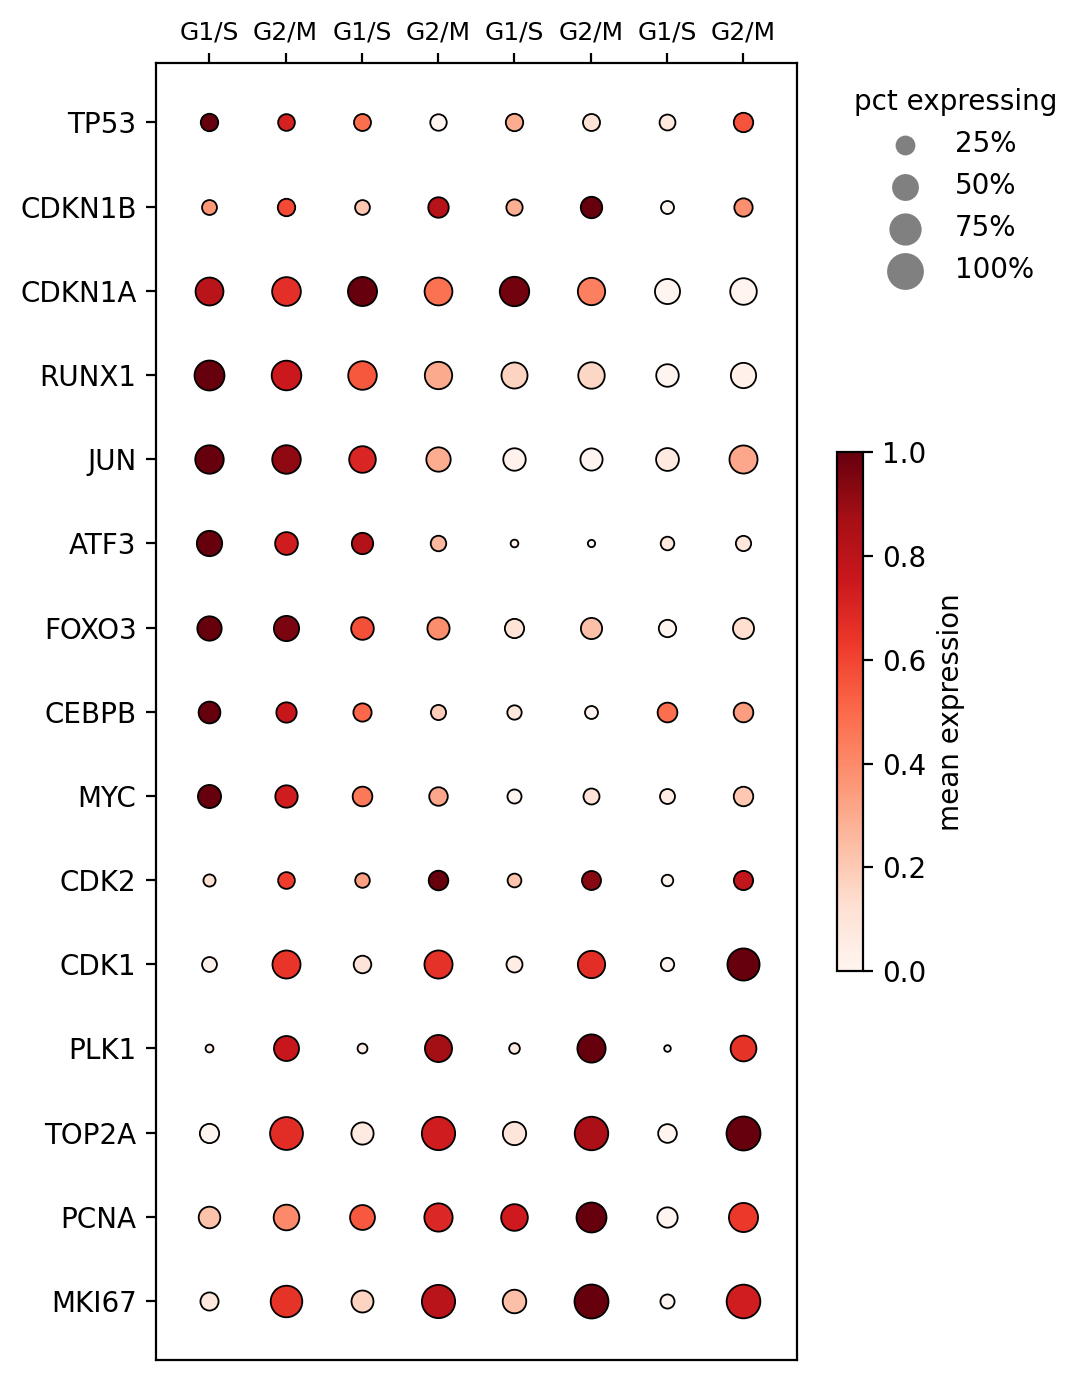

In [185]:
genes = [
    'MKI67', 'PCNA', 'TOP2A', 'PLK1', 'CDK1', 'CDK2', 'MYC',
    
    'CEBPB', 'FOXO3', 'ATF3', 'JUN', 'RUNX1', 'CDKN1A', 'CDKN1B', 'TP53',
]


# genes = [
    

genes_to_plot = [g for g in genes if g in adata.var_names]


groups = [
    'mmMYOD1_G1S', 'mmMYOD1_G2M',
    'siPRRX1/mmMYOD1_G1S', 'siPRRX1/mmMYOD1_G2M',
    'siPRRX1_G1S', 'siPRRX1_G2M',
    'Control_G1S', 'Control_G2M',
]
    

avg_expr = pd.DataFrame(index=genes_to_plot, columns=groups)
pct_expr = pd.DataFrame(index=genes_to_plot, columns=groups)

adata.X = adata.layers['log_norm'].copy()

for g in groups:
    # cells = adata.obs['leiden_split'] == g
    cells = adata.obs['cond_phase_group'] == g
    data = adata[cells, genes_to_plot].X
    # If sparse matrix
    if not isinstance(data, np.ndarray):
        data = data.toarray()
    avg_expr[g] = data.mean(axis=0)
    pct_expr[g] = (data > 0).mean(axis=0) * 100

    
avg_expr_scaled = (avg_expr.T - avg_expr.min(axis=1)) / (avg_expr.max(axis=1) - avg_expr.min(axis=1))
avg_expr_scaled = avg_expr_scaled.T
    
# # Z-score by gene
# avg_expr = avg_expr.T   
# avg_expr_z = avg_expr.apply(scipy.stats.zscore, axis=0)
# avg_expr_z = avg_expr_z.T

# print(avg_expr_z.shape)
# avg_expr_z.head()  

cmap = 'Reds'
size_scale = 1.5

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 5.5, 7
fig, ax = plt.subplots()

for i, gene in enumerate(genes_to_plot):
    for j, cluster in enumerate(groups):
        size = float(pct_expr.loc[gene, cluster])*size_scale
        color = float(avg_expr_scaled.loc[gene, cluster])
        
        ax.scatter(
            x=j, 
            y=i, 
            s=size, 
            c=[color], 
            linewidths=0.65,
            edgecolors='k',
            cmap=cmap,
            vmin=0, 
            vmax=1, 
        )
        
ax.set_yticks(range(len(genes_to_plot)))
ax.set_yticklabels(genes_to_plot)

ax.set_xticks(range(len(groups)))

plot_labels = ['G1/S', 'G2/M'] * 4
ax.set_xticklabels(plot_labels, fontsize=9)#, rotation=90)

ax.xaxis.set_label_position('top') 
ax.xaxis.tick_top()
ax.set_xlabel('')

ax.margins(x=0.1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.05)
cbar.set_label('mean expression')


sizes = [25, 50, 75, 100]
markers = [plt.scatter([], [], s=s*size_scale, color='gray') for s in sizes]
labels = [f"{s}%" for s in sizes]

ax.legend(markers, labels, title="pct expressing", scatterpoints=1,
          frameon=False, bbox_to_anchor=(1.05, 1), loc='upper left')


plt.tight_layout()
plt.show()